In [1]:
import sys
import pickle
import copy

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mplcolors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import seaborn as sns
import matplotlib.lines as mlines
from sklearn.cluster import KMeans

import cartopy.crs as ccrs
import cartopy


from tqdm.notebook import tqdm

root_path = '../' # This defaults to './', which should be the repository path
data_path = "/media/data/system_split/data/"
results_path = "/media/data/system_split/results/"
sys.path.append(root_path)
from utils import data_handling, cascade_simulation

n_nodes = 400

path_to_pypsa_network = data_path + 'European_networks_sclopf/'
path_to_cascade_results = results_path + 'sclopf/cascade_results/'
path_to_vis_results = results_path + 'sclopf/split_visualization/'
path_to_pre_outage = results_path + 'sclopf/pre_outage_data_{n_nodes}/'
path_to_eval_results = results_path + 'sclopf/evaluation_results/'
path_to_inertia = results_path + 'sclopf/inertia_placement/'
save_path = root_path + 'figures/sclopf/'


# Setup

In [2]:
# Load network graph and node positions
# (it is equal for all CO2 levels)
snet_index = 0
network = data_handling.load_pypsa_network(0.5, n_nodes, path_to_pypsa_network)
nx_graph = data_handling.build_networkx_graph(network, snet_index= snet_index)
pos = nx.get_node_attributes(nx_graph, 'pos')
I_m, B_d, num_parallels, line_limits = data_handling.get_matrices_from_nx_graph(nx_graph)

# Determine number of simulations,
# i.e., total number of initial failures over the simulated period of one year
bridge_idxs = data_handling.nx_edges_to_matrix_indices(nx.bridges(nx_graph),
                                                           nx_graph)
n_2_failures = cascade_simulation.calc_possible_double_line_failures(num_parallels,
                                                                     ignored_idxs=bridge_idxs)
num_failures = len(n_2_failures)
num_failures_weighted = network.snapshot_weightings.objective.sum() * num_failures

/home/mtitz/.conda/envs/system_split/lib/python3.8/site-packages/xarray/backends/plugins.py:71: RuntimeWarning: Engine 'cfgrib' loading failed:
Cannot find the ecCodes library
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


In [3]:
co2ls = np.arange(0.0,0.81,0.1).round(1)
# selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])
selected_co2ls = np.array([0.0, 0.2, 0.6])

# Figure 2

In [5]:
generation_by_carrier_and_co2l = pd.DataFrame(index=network.carriers.index,
                                              columns=co2ls)
objectives = np.zeros(len(co2ls))
for i, level in enumerate(co2ls):
    network = data_handling.load_pypsa_network(level, n_nodes, path_to_pypsa_network)
    generation_by_carrier_and_co2l[level] = network.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").mul(network.generators.sign).T.groupby(
        network.generators["carrier"]).sum().sum(axis=1)
    objectives[i] = network.objective
generation_by_carrier_and_co2l.dropna(axis=0, inplace=True)
# drop the 0.7 and 0.8 columns because they carry no relevant information, see old plots
generation_by_carrier_and_co2l.drop(columns=[0.7, 0.8], inplace=True)

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.3-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.4-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
/home/mtitz/.conda/envs/system_split/lib/python3.8/site-packages/cartopy/mpl/style.py:76: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


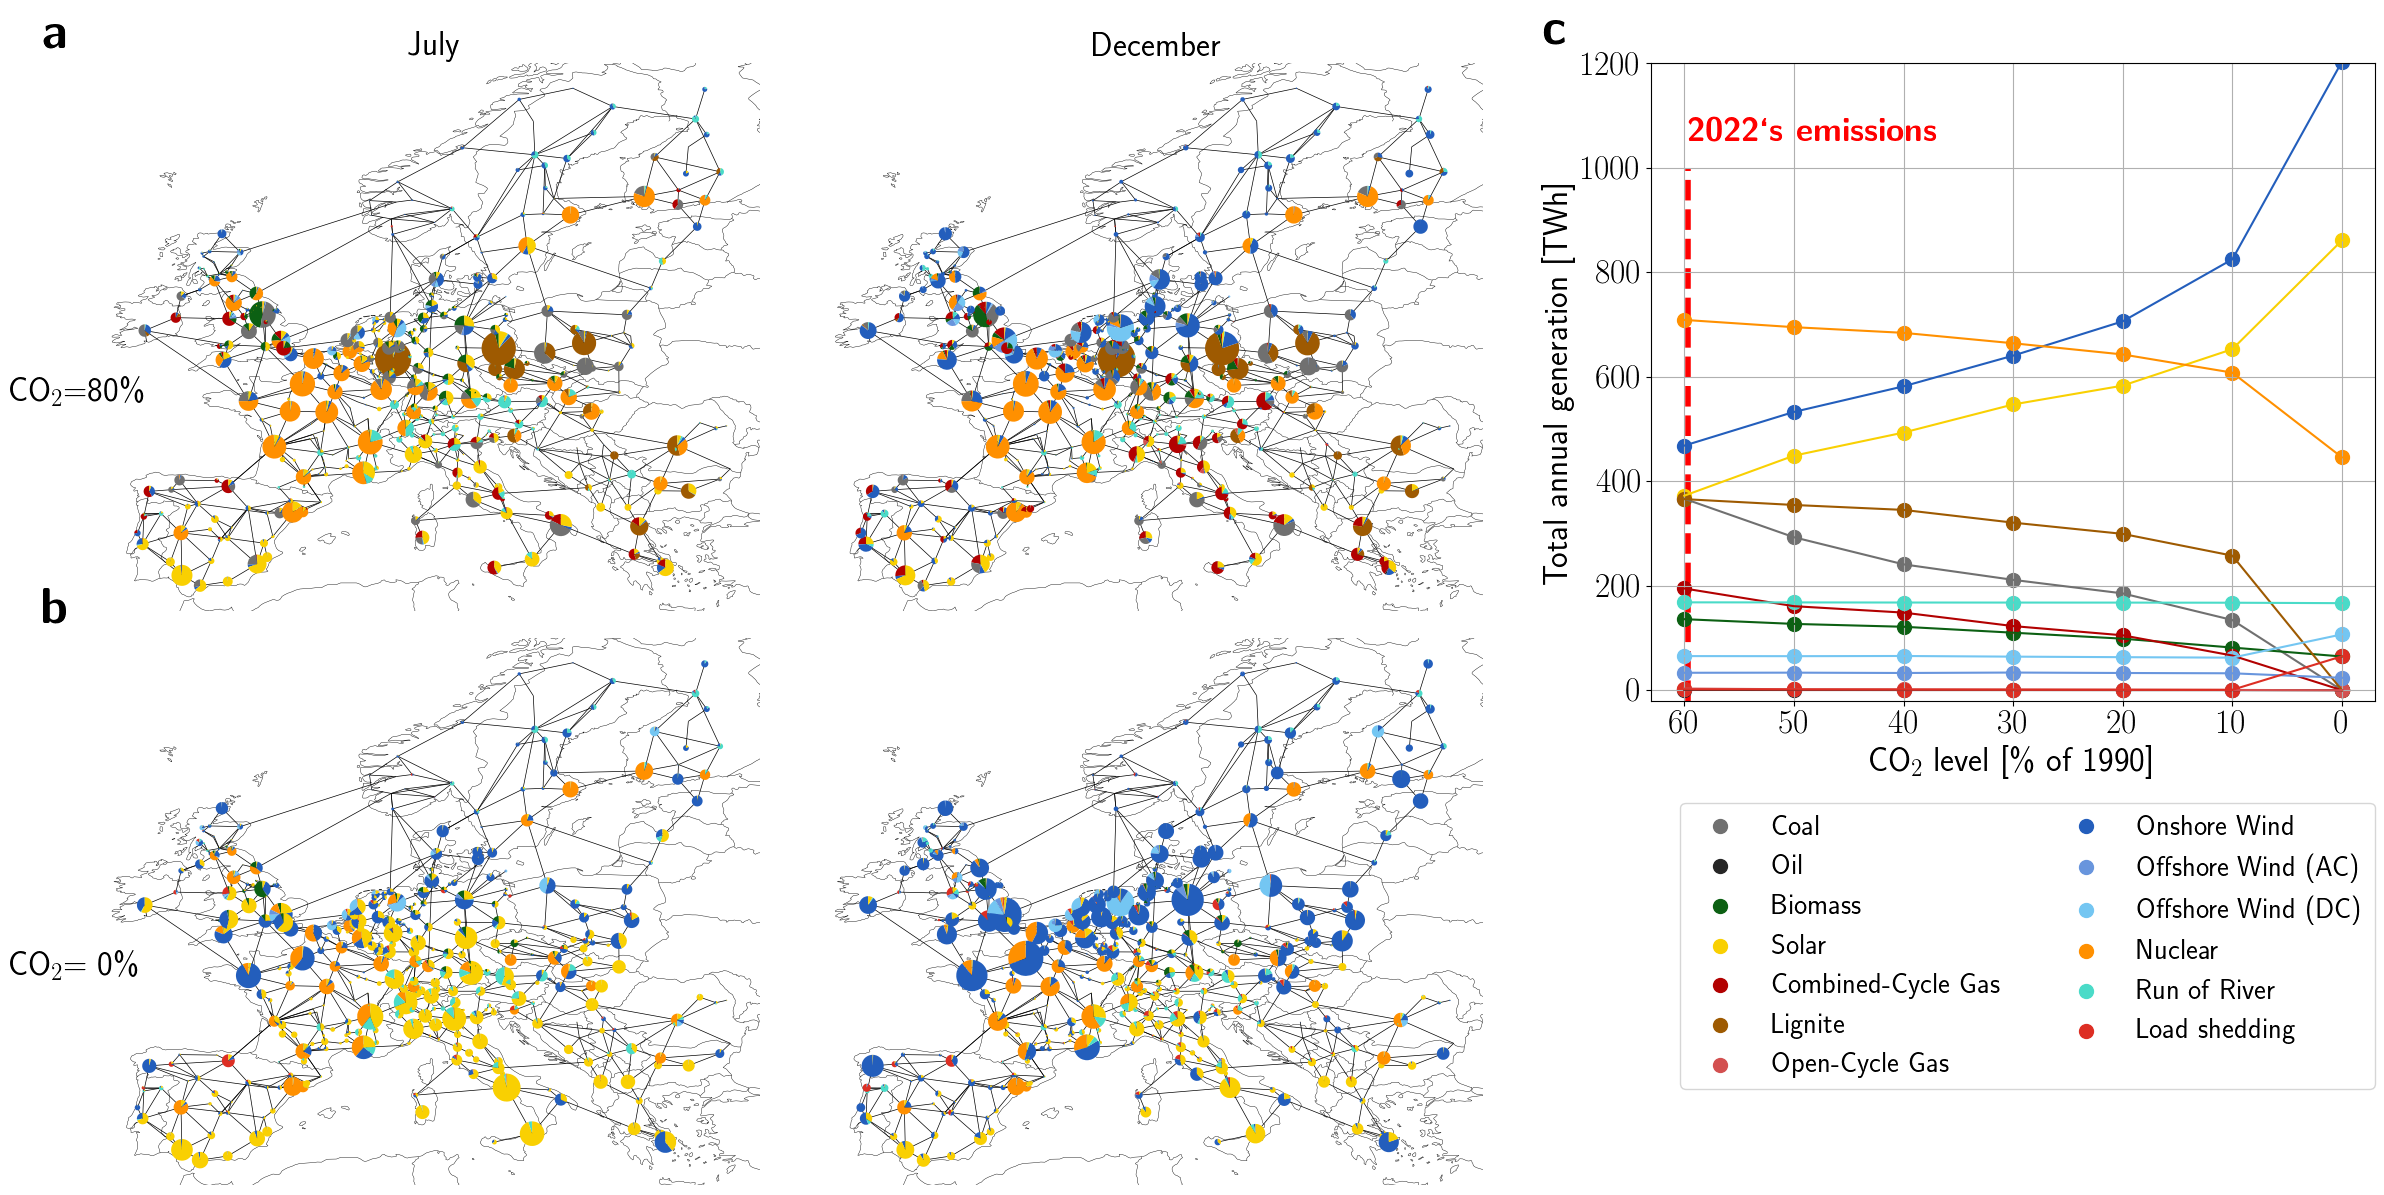

In [6]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.6, 0.0]

f = plt.figure(figsize=(24, 12))
# gs = GridSpec(2, 3, figure=f)
# ax1 = [f.add_subplot(gs[0, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# ax2 = [f.add_subplot(gs[1, i], projection=ccrs.PlateCarree())
#        for i in range(2)]
# axs_clust = [ax1, ax2]
# ax3 = f.add_subplot(gs[0, 2])
outer = GridSpec(1, 2, width_ratios = [2, 1]) 
# gs = GridSpec(2, 3, figure=f)
gs_left = GridSpecFromSubplotSpec(2, 2, subplot_spec = outer[0], wspace=-0.0, hspace=0.05)
gs_right = GridSpecFromSubplotSpec(2, 1, subplot_spec = outer[1], height_ratios=[1, 0.6])

ax1 = [f.add_subplot(gs_left[0, i], projection=ccrs.PlateCarree())
       for i in range(2)]
ax2 = [f.add_subplot(gs_left[1, i], projection=ccrs.PlateCarree())
       for i in range(2)]
axs_clust = [ax1, ax2]
ax3 = f.add_subplot(gs_right[0, 0])
ax3_legend = f.add_subplot(gs_right[1, 0])
# ax4 = f.add_subplot(outer[1, 1])
labels = [[r'\textbf{a}', r'', r'\textbf{c}'],
          [r'\textbf{b}', '', r'\textbf{d}', '', '']]

##### panal a and b #######

vmax = 3.2e2
months = [7, 12]

for i, target_level in enumerate(target_levels):
    n = data_handling.load_pypsa_network(target_level, n_nodes, path_to_pypsa_network)
    for j, month in enumerate(months):

        axs_clust[i][j].set_ylim([0, vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]
        current_gen = n.generators_t.p.mul(network.snapshot_weightings.generators, axis="index").loc[current_snapshots].sum().mul(network.generators.sign)
        current_gen = current_gen.groupby([n.generators["bus"], n.generators["carrier"]]).sum()
        n.plot(bus_sizes=current_gen/7e6,
               line_colors='black',
               link_colors='black',
               link_widths=0.5,
               line_widths=0.5,
               ax=axs_clust[i][j])

        if i == 0:
            axs_clust[i][j].set_title(current_snapshots.month_name()[0], fontsize=24)

        axs_clust[i][j].text(0 - 0.1, 1+0.05,
                       labels[i][j],
                       fontsize=36,
                       weight='bold',
                       verticalalignment='center',
                       transform=axs_clust[i][j].transAxes)


axs_clust[0][0].text(0 - 0.15, 0.4,
               r'CO$_2$=80\% ',
               fontsize=24,
               verticalalignment='center',
               transform=axs_clust[0][0].transAxes)
axs_clust[1][0].text(0 - 0.15, 0.4,
               r'CO$_2$= 0\%',
               fontsize=24,
               verticalalignment='center',
               transform=axs_clust[1][0].transAxes)

###### panel c ######

co2s = generation_by_carrier_and_co2l.columns.astype('float')
index = np.argsort(co2s)
generation_by_carrier_and_co2l = generation_by_carrier_and_co2l.rename(index=network.carriers.nice_name)
for ind,data in generation_by_carrier_and_co2l.iterrows():
    ax3.scatter(co2s[index]*100,
                (data.values)[index]*1e-6,
                color=n.carriers.set_index('nice_name').color.loc[ind],
                label=ind,
                s=100)

    ax3.plot(co2s[index]*100,
             (data.values)[index]*1e-6,
             color=n.carriers.set_index('nice_name').color.loc[ind])


ax3.invert_xaxis()
ax3.tick_params(axis='both', which='both', labelsize=24)
ax3.set_xlabel(r'$\text{CO}_2$ level [\% of 1990]',  fontsize=24)
ax3.set_ylabel(r'Total annual generation [TWh]', fontsize=24)

ax3.grid(True)
ax3.yaxis.offsetText.set_fontsize(24)
ax3.text(0 - 0.15, 1+0.05,
         labels[0][2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax3.plot([746/1251*100, 746/1251*100],[-2e1,1000], '--', lw=4, c='r', zorder=-1000) # TODO: Insert CO2 limit that corresponds to todays amount
# co2 emissions from https://www.umweltbundesamt.de/daten/klima/treibhausgas-emissionen-in-deutschland#emissionsentwicklung
# ax3.text(50,12e2*0.9, r'\textbf{2022`s emissions}', fontsize=24, color='r')
ax3.text(746/1251*100,1050, r'\textbf{2022`s emissions}', fontsize=24, color='r', horizontalalignment='left')
ax3.set_ylim([-2e1,12e2])
# ax3.set_yscale('log')

# f.subplots_adjust(hspace=0.05, wspace=0.2)
h, l = ax3.get_legend_handles_labels()
ax3_legend.legend(h, l, borderaxespad=0, fontsize=20.5, ncol=2)
ax3_legend.axis("off")
# ax3.legend(fontsize=20.5, bbox_to_anchor=(1.02,0), ncol=2, loc="upper left")
# plt.tight_layout()
# ax3.legend(fontsize=20.5, ncol=2, columnspacing=0.5, handletextpad=0.1, borderpad=0.3)
plt.tight_layout()

plt.savefig(save_path+'fig2.pdf', bbox_inches='tight')

ToDo: Monthly/annual sums of generation should be weighted be length of time stamps!!! Because time steps are not equidistant anymore. TW -> TWh. Done

ToDo: change marker size in a/b?

In [21]:
# check whether network is balanced all the time...
for co2l in co2ls:
    network = data_handling.load_pypsa_network(co2l, n_nodes, path_to_pypsa_network)

    for timestamp in network.snapshots:

        current_generation = network.generators_t.p.loc[timestamp].mul(network.generators.sign).copy()
        current_storage    = network.storage_units_t.p.loc[timestamp]
        current_load       = network.loads_t.p.loc[timestamp]
        
        if np.abs(current_generation.sum()+current_storage.sum()-current_load.sum())>1e-1:
            print('Warning: Power imbalance for', timestamp, 'and CO2 level', co2l, 'is non-zero:')
            print(np.abs(current_generation.sum()+current_storage.sum()-current_load.sum()), '[MW]')

INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.0-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units


INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.1-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.2-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.3-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.4-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.5-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa.io:Imported network sclopf-elec_s_400_ec_lv1.0_Co2L0.6-2920SEG.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
INFO:pypsa

# Figure 4

In [8]:
inertia_time = np.load(path_to_pre_outage +
                       'inertia_time_series_all_co2ls.npy')
inertia_generation = np.load(
    path_to_pre_outage + 'min_max_nodal_inertia_generation_all_co2ls.npy')


1619.4745183228827
271.6858748095594
878.442644303537
84.60615703485763


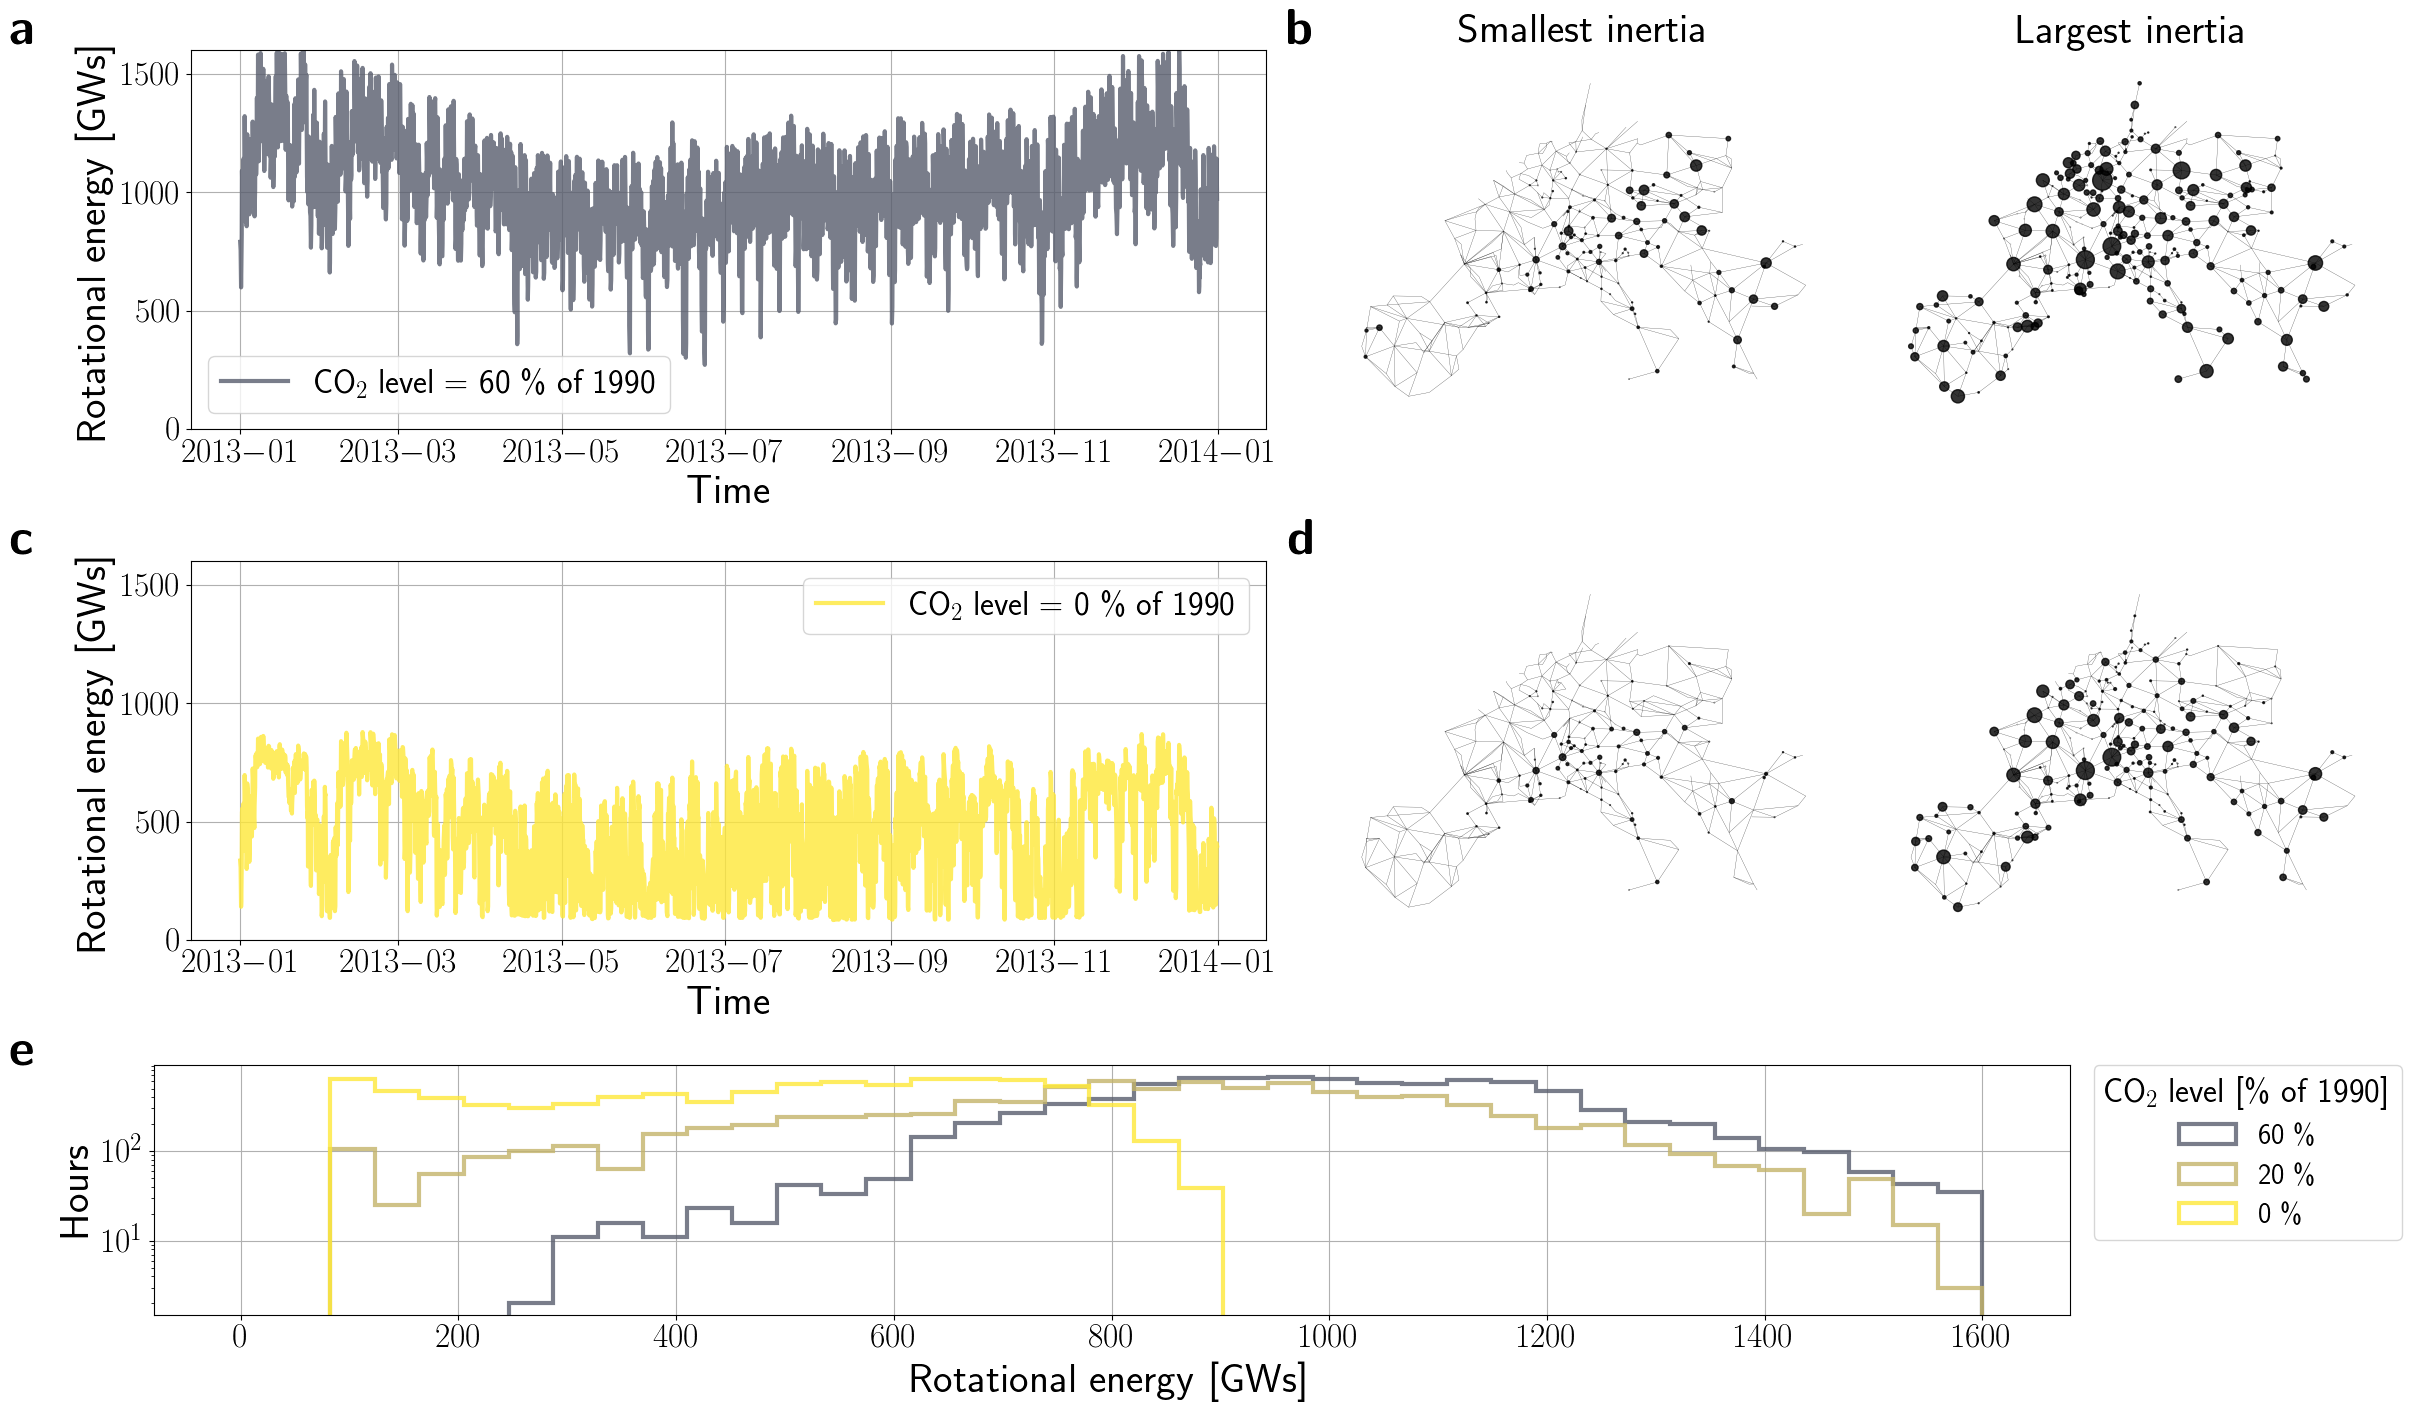

In [21]:
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}'], [r'\textbf{e}']]
f = plt.figure(figsize=(24, 14), constrained_layout=True)
gs = GridSpec(3, 4, figure=f)
gs_probs = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2, :], width_ratios=[8, 1])
axs_probs_plot = f.add_subplot(gs_probs[0, 0])
axs_probs_legend = f.add_subplot(gs_probs[0, 1])
ax2 = f.add_subplot(gs[0, :2])
ax3 = f.add_subplot(gs[1, :2])
ax21 = f.add_subplot(gs[0, 2])
ax22 = f.add_subplot(gs[0, 3])
ax31 = f.add_subplot(gs[1, 2])
ax32 = f.add_subplot(gs[1, 3])
axs_clust = [[ax21, ax22], [ax31, ax32]]


########## panel  e: inertia histograms ############

cmap = plt.get_cmap('cividis_r')
bins = np.linspace(0, 1600, 40)

for count, level in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    # ax.hist(np.repeat(inertia_time[ind], network.snapshot_weightings.generators)/1000,
    axs_probs_plot.hist(inertia_time[ind]/1000,
            weights=network.snapshot_weightings.generators,
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(level*100)),
            linewidth=3,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs_plot.xaxis.offsetText.set_fontsize(24)

leg = axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
h, l = axs_probs_plot.get_legend_handles_labels()
leg = axs_probs_legend.legend(h, l, borderaxespad=0, fontsize=20.5, title=r'CO$_2$ level [\% of 1990]')
# axs_probs_legend.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
axs_probs_legend.axis("off")
# leg=axs_probs_plot.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')

plt.setp(leg.get_title(),fontsize=24)
axs_probs_plot.tick_params(axis='both', which='both', labelsize=24)
axs_probs_plot.set_xlabel('Rotational energy [GWs]',  fontsize=30)
axs_probs_plot.set_ylabel('Hours', fontsize=30)
axs_probs_plot.set_yscale('log')
axs_probs_plot.grid()
axs_probs_plot.get_legend().remove()

#ax.set_xlim([0,2.1e3/6*1.1])


############# panels a and c: inertia time series ################

axes = [ax2, ax3]

for j, level in enumerate(target_levels):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    print(np.amax(inertia_time[ind]/1000))
    print(np.amin(inertia_time[ind]/1000))
    axes[j].plot(network.snapshots,
                 inertia_time[ind]/1000,
                 color=cmap(ind/len(co2ls)),
                 lw=3,
                 alpha=0.8,
                 label=r'$\text{CO}_2\text{ level} =$ '+ '{} \% of 1990'.format(int(level*100)))
    axes[j].legend(fontsize=24)
    axes[j].tick_params(axis='both', which='both', labelsize=24)
    axes[j].set_ylabel('Rotational energy [GWs]', fontsize=30)
    axes[j].set_xlabel('Time', fontsize=30)
    axes[j].set_ylim([0, 1600])
    axes[j].yaxis.offsetText.set_fontsize(24)
    axes[j].grid()


########### panels b and d: maps with nodal inertia ###############

target_levels = [0.60, 0.00]
titles = ['Smallest inertia', 'Largest inertia']

for j, level in enumerate(target_levels):

    ind = np.where(co2ls == level)[0][0]
    
    for i in range(len(titles)):
        nx.draw_networkx_nodes(nx_graph,
                               pos,
                               ax=axs_clust[j][i],
                               node_size=inertia_generation[ind, i]/300,
                               alpha=0.8,
                               node_color='black')
        nx.draw_networkx_edges(nx_graph,
                               pos,
                               ax=axs_clust[j][i],
                               alpha=0.8,
                               width=0.2)
        if j == 0:
            axs_clust[j][i].set_title(titles[i], fontsize=30)
        axs_clust[j][i].axis('off')

# panel labels
ax3.text(0 - 2.25*0.075, 1+0.05,
         labels[1][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax3.transAxes)
ax2.text(0 - 2.25*0.075, 1+0.05,
         labels[0][0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)
ax31.text(0 - 0.05, 1+0.05,
          labels[1][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax31.transAxes)
ax21.text(0 - 0.05, 1+0.05,
          labels[0][1],
          fontsize=36,
          weight='bold',
          verticalalignment='center',
          transform=ax21.transAxes)
axs_probs_plot.text(0 - 0.075, 1+0.05,
        labels[2][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs_plot.transAxes)


plt.savefig(save_path+'fig4.pdf',bbox_inches = 'tight')


ToDo: Histogram probabilities should be weighted with snapshot length! Instead of 'Count' use 'Hours' on y-axis. Done

Time series do not have to be changed, they can be plotted against network.snapshots!

# Figure 3

In [23]:
mean_consumption_vector = np.load(
    path_to_pre_outage + 'mean_nodal_consumption_all_co2ls.npy')
weighted_mean_consumption_vector = np.load(
    path_to_pre_outage + 'weighted_mean_nodal_consumption_all_co2ls.npy')
dipole_vector = np.load(path_to_pre_outage +
                        'dipole_vector_time_series_all_co2ls.npy')
vec_norm = np.load(path_to_pre_outage + 'spi_time_series_all_co2ls.npy')


Figure 3


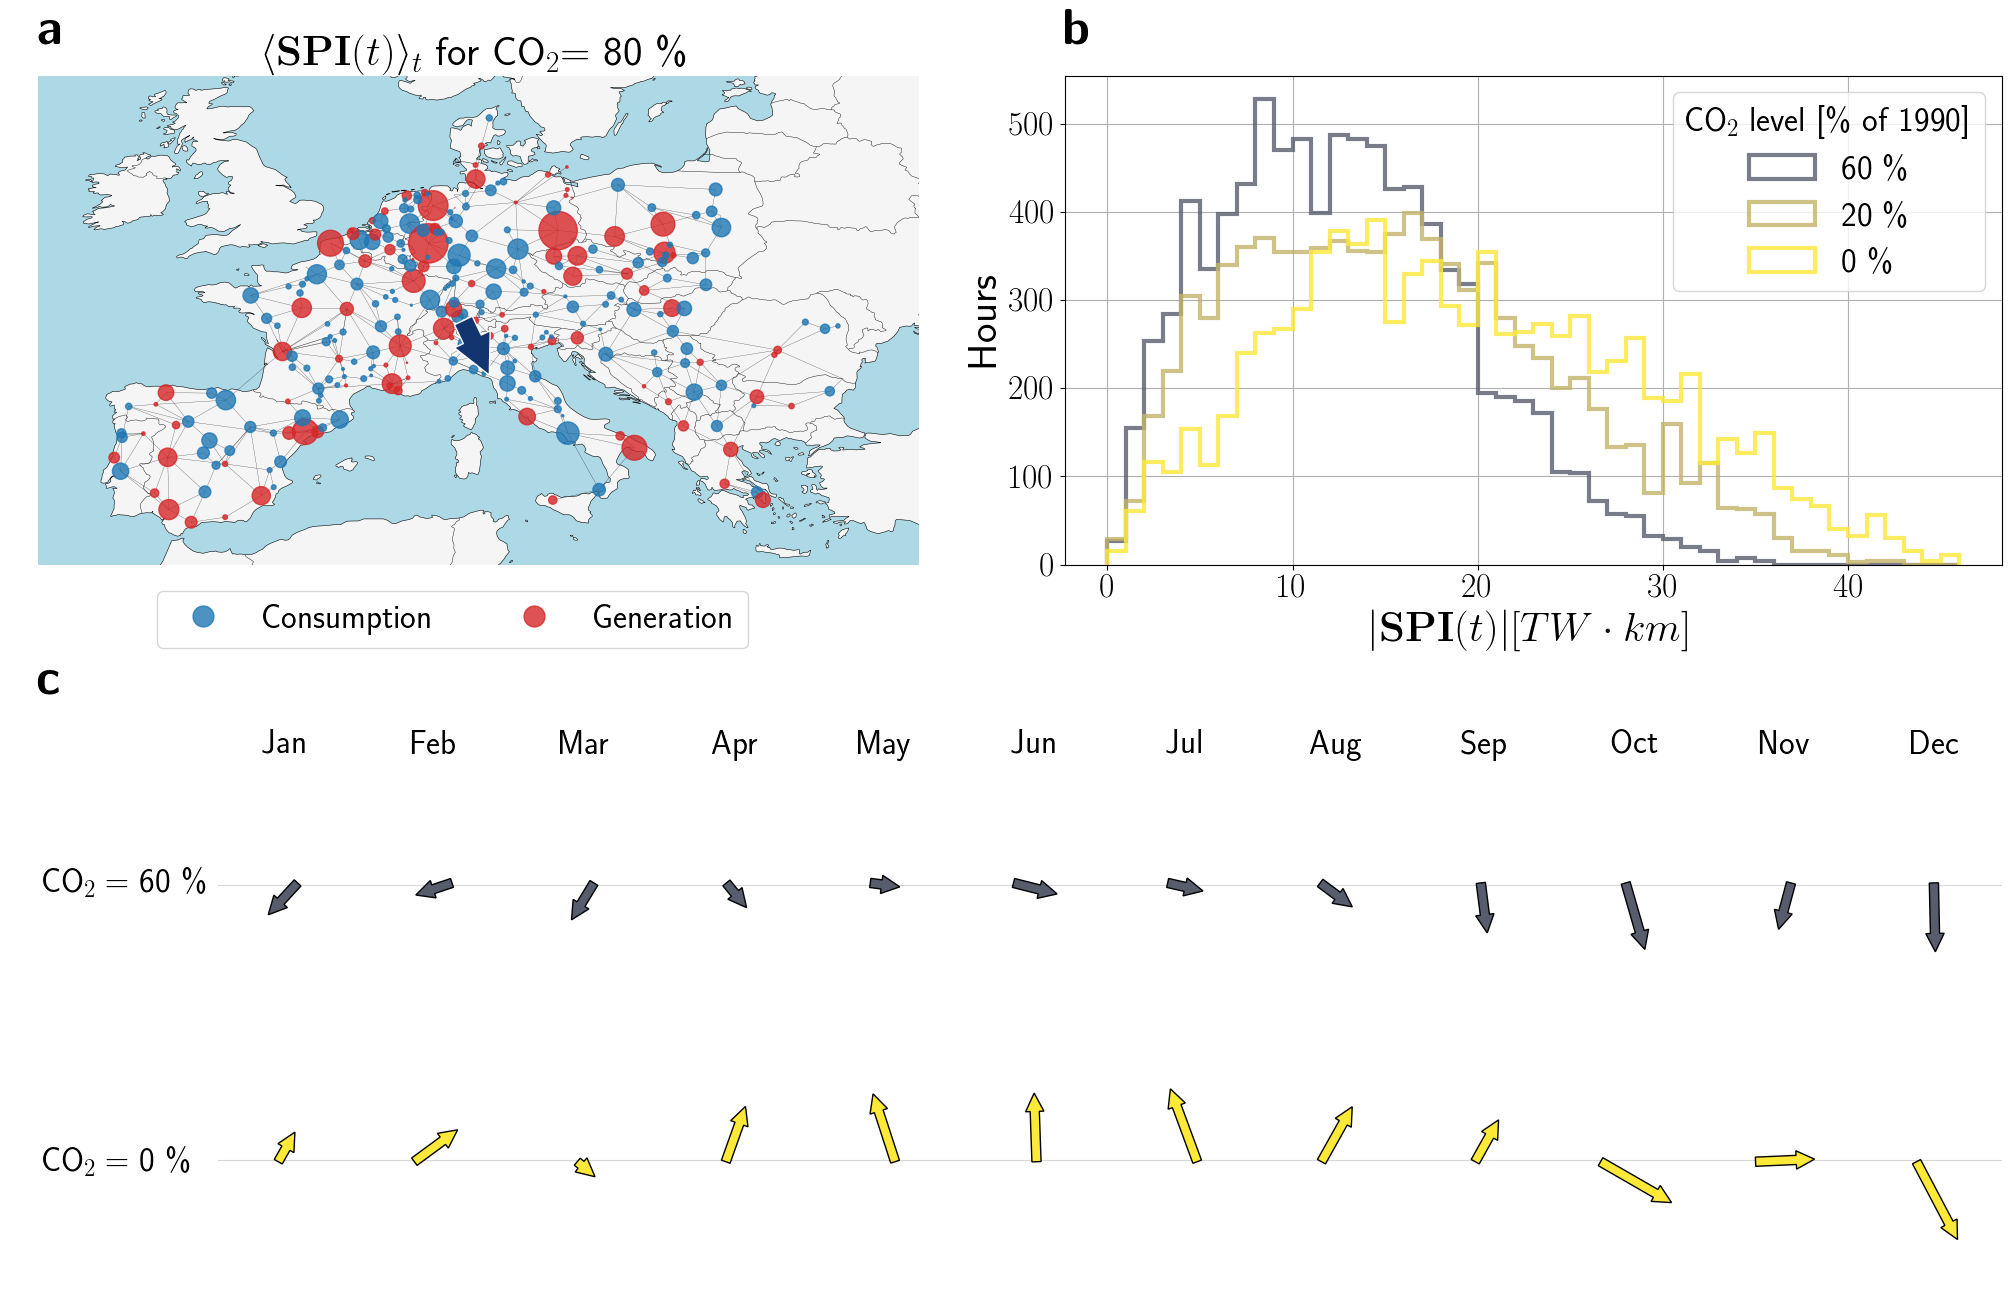

In [40]:
print("Figure 3")

mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
labels = [[r'\textbf{a}', r'\textbf{b}'], [
    r'\textbf{c}', r'\textbf{d}', r'\textbf{e}', r'\textbf{f}']]

f = plt.figure(figsize=(20, 13), constrained_layout=True)
gs0= GridSpec(2,1, figure=f, hspace=0.9) # outer grid
gs1 = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs0[0])
axs_probs = f.add_subplot(gs1[0], projection=ccrs.PlateCarree())
ax2 = f.add_subplot(gs1[1])
gs2 = GridSpecFromSubplotSpec(2, 13, subplot_spec=gs0[1], hspace=0)
# axs_leg = f.add_subplot(gs0[0,0])
# axs_leg.axis('off')
axs_co2_0 = f.add_subplot(gs2[0, 0])
axs_co2_1 = f.add_subplot(gs2[1, 0])
axs_co2_0.axis('off')
axs_co2_1.axis('off')

axs_clust = [f.add_subplot(gs2[0, i+1], projection=ccrs.PlateCarree())
       for i in range(12)]
axs2 = [f.add_subplot(gs2[1, i+1], projection=ccrs.PlateCarree())
        for i in range(12)]


##########  panel a : Mean SPI on map for 80% co2 level  ###################

resolution = "50m"
color_geomap = {'ocean': 'lightblue', 'land': 'whitesmoke'}

axs_probs.add_feature(cartopy.feature.LAND.with_scale(resolution),
               facecolor=color_geomap['land'])
axs_probs.add_feature(cartopy.feature.OCEAN.with_scale(resolution),
               facecolor=color_geomap['ocean'])
axs_probs.coastlines(linewidth=0.4, zorder=2, resolution=resolution)
border = cartopy.feature.BORDERS.with_scale(resolution)
axs_probs.add_feature(border, linewidth=0.3)
cmap = plt.get_cmap('cividis_r')
position_vector = np.array([pos[n] for n in nx_graph.nodes()])
mean_pos = [np.mean(position_vector[:, 0]), np.mean(position_vector[:, 1])]


nx.draw_networkx_edges(nx_graph,
                       pos,
                       ax=axs_probs,
                       alpha=0.8,
                       width=0.2)

scale_factor = 2e4

# current_vec = np.mean(dipole_vector, axis=2)
# use average weighted by snapshot weight
current_vec = np.average(dipole_vector, weights=network.snapshot_weightings.generators, axis=2)

vec = weighted_mean_consumption_vector
plot_co2ls = [0.8]

for i, level in enumerate(plot_co2ls):

    ind = np.where(np.round(co2ls, 2) == level)[0][0]

    node_colours = ['tab:red' if vec[ind, i] <
                    0 else 'tab:blue' for i in range(len(nx_graph.nodes()))]

    nx.draw_networkx_nodes(nx_graph,
                           pos,
                           ax=axs_probs,
                           node_size=np.abs(vec[ind])/30,
                           node_color=node_colours,
                           alpha=0.8)

    axs_probs.arrow(mean_pos[0],
             mean_pos[1],
             current_vec[ind, 0]/scale_factor,
             current_vec[ind, 1]/scale_factor,
             head_width=2.0,
             width=1.0,
             head_length=2.0,
            #  alpha  = 1,
             facecolor=cmap(ind/len(co2ls)),
            #  facecolor="cmap(ind/len(co2ls))",
             edgecolor="white",
             zorder=np.inf)
    axs_probs.axis('off')


# add legend

blue_circle = mlines.Line2D([], [], color='tab:blue', marker='o', linestyle='None',
                          markersize=15, label='Consumption', alpha=0.8)
red_circle = mlines.Line2D([], [], color='tab:red', marker='o', linestyle='None',
                          markersize=15, label='Generation', alpha=0.8)
axs_probs.legend(handles=[blue_circle,red_circle], bbox_to_anchor=(0.825,-0.02,0,0), ncol=2, fontsize=24)


########### panel b: Histogrms of SPI norm ##############

bins = np.arange(0, np.quantile(vec_norm, 0.9999), 1)  # np.arange(0,0.08,0.001)#


for i, level in enumerate(selected_co2ls[::-1]):

    # weighted_vec_norm = np.repeat(vec_norm[np.where(co2ls == level)[0][0],:], network.snapshot_weightings.generators.values.astype(int))
    
    ind = np.where(co2ls == level)[0][0]
    ax2.hist(
            # weighted_vec_norm,
            vec_norm[ind],
            weights=network.snapshot_weightings.generators.values.astype(int),
             bins=bins,
             histtype='step',
             label='{} \%'.format(int(level*100)),
             linewidth=3,
             color=cmap(ind/len(co2ls)),
             #density=True,
             alpha=0.8)
leg=ax2.legend(fontsize=24, title=r'CO$_2$ level [\% of 1990]')
plt.setp(leg.get_title(),fontsize=24)
ax2.tick_params(axis='both', which='both', labelsize=24)
ax2.set_xlabel(r'$|\mathbf{SPI}(t)| [TW\cdot km]$', fontsize=30)
ax2.set_ylabel('Hours', fontsize=30)
ax2.grid(True)
ax2.yaxis.offsetText.set_fontsize(24)

############   panel c: Seasonal dependency of SPI vectors ##################

old_ind = 0

for j in range(12):

    new_ind = old_ind + \
        len(network.snapshots[network.snapshots.month == int(j+1)])

    current_level = 0.6
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    # for mean use np.average with weights

    axs_clust[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))


    current_vec = np.median(dipole_vector[:, :, old_ind:new_ind], axis=2) # maybe take mean?!
    
    current_level = 0.0
    ind = np.where(co2ls == current_level)[0][0]

    current_vec_0 = np.median(np.repeat(dipole_vector[ind, 0, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!
    current_vec_1 = np.median(np.repeat(dipole_vector[ind, 1, old_ind:new_ind], network.snapshot_weightings.generators.values[old_ind:new_ind].astype(int))) # maybe take mean?!

    axs2[j].arrow(mean_pos[0],
                                    mean_pos[1],
                                    current_vec_0/scale_factor,
                                    current_vec_1/scale_factor,
                                    head_width=2.0,
                                    width=1.0,
                                    head_length=2.0,
                                    #alpha  = .8,
                                    facecolor=cmap(ind/len(co2ls)))
    
    
    axs_clust[j].axis('off')
    axs2[j].axis('off')
    
    axs_clust[j].set_ylim([31.707498915424157, 60.29928495567561])
    axs2[j].set_ylim([31.707498915424157, 60.29928495567561])

    old_ind = new_ind

# common grid behind spi vectors
axs_grid = f.add_subplot(gs2[:,1:], zorder=-1)
for _, spine in axs_grid.spines.items():
    spine.set_visible(False)
axs_grid.tick_params(labelleft=False, labelbottom=False, bottom=False, left=False, right=False )
axs_grid.set_yticks([0.26, 0.77])
#axs_grid.set_xlim([0,12])
#axs_grid.set_xticks(np.arange(1,12)-0.2)
axs_grid.grid(axis='y', alpha=0.5)



###########  panel labels ###################

ax2.text(0, 1+0.09,
         labels[0][1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=ax2.transAxes)

axs_probs.text(0, 1+0.09,
        labels[0][0],
        fontsize=36,
        weight='bold',
        verticalalignment='center',
        transform=axs_probs.transAxes)

axs_co2_0.text(0.2, 1+0.3,
                    labels[1][0],
                    fontsize=36,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_co2_0.transAxes)

# axs_co2.text(0.5, 0.25, r'\textbf{c}', fontsize=36,
#                     weight='bold',
#                     verticalalignment='center',)#, rotation=90, horizontalalignment='center')
# axs_co2_0.text(0.5, 0.25, r'\textbf{c}', fontsize=24, rotation=90, horizontalalignment='center')
axs_co2_0.text(0.25, 0.5, r'CO$_2 =$ 60 \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_1.text(0.25, 0.5, r'CO$_2 =$ 0 \%', fontsize=24, rotation=0, horizontalalignment='left')
axs_co2_0.axis('off')

axs_probs.set_title(r'$\langle \mathbf{SPI}(t)\rangle_t$ for CO$_2$= 80 \%', fontsize=30)


for j in range(12):
    axs_clust[j].set_title(network.snapshots[network.snapshots.month == j+1][0].month_name()[:3],
                                       fontsize=24,
                                       pad=0)
plt.savefig(save_path+'fig3.pdf',bbox_inches = 'tight')

ToDo: Use snapshots weighting for averages! Done

# Figure 7

Note: These are the likelihoods for ANY split that occured, i.e., also those with only 1 or 2 nodes being split off. Should we keep it like this?

Important: When setting vmin larger then the minimum probability, then edges with likelihood below vmin appear as gray, which might be confused with a line that never leads to a blackout. So: Check vmin/vmax configuration and maybe explain in figure legend. 

In [42]:
edge_likelihoods_primary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_primary_all_co2ls_n{n_nodes}.pickle', 'rb'))
edge_likelihoods_secondary = pickle.load(
    open(path_to_vis_results+f'edge_likelihoods_secondary_all_co2ls_n{n_nodes}.pickle', 'rb'))


In [43]:
# Minimum probability
# number_of_simulations = len(n_2_failures)*network.snapshots.size
# 1/number_of_simulations

/tmp/ipykernel_23222/1091505004.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))


Min val prim: 4.986506e-08
Max val prim: 4.479777e-04
Min val prim: 9.973012e-09
Max val prim: 5.787680e-04


KeyError: 0.0

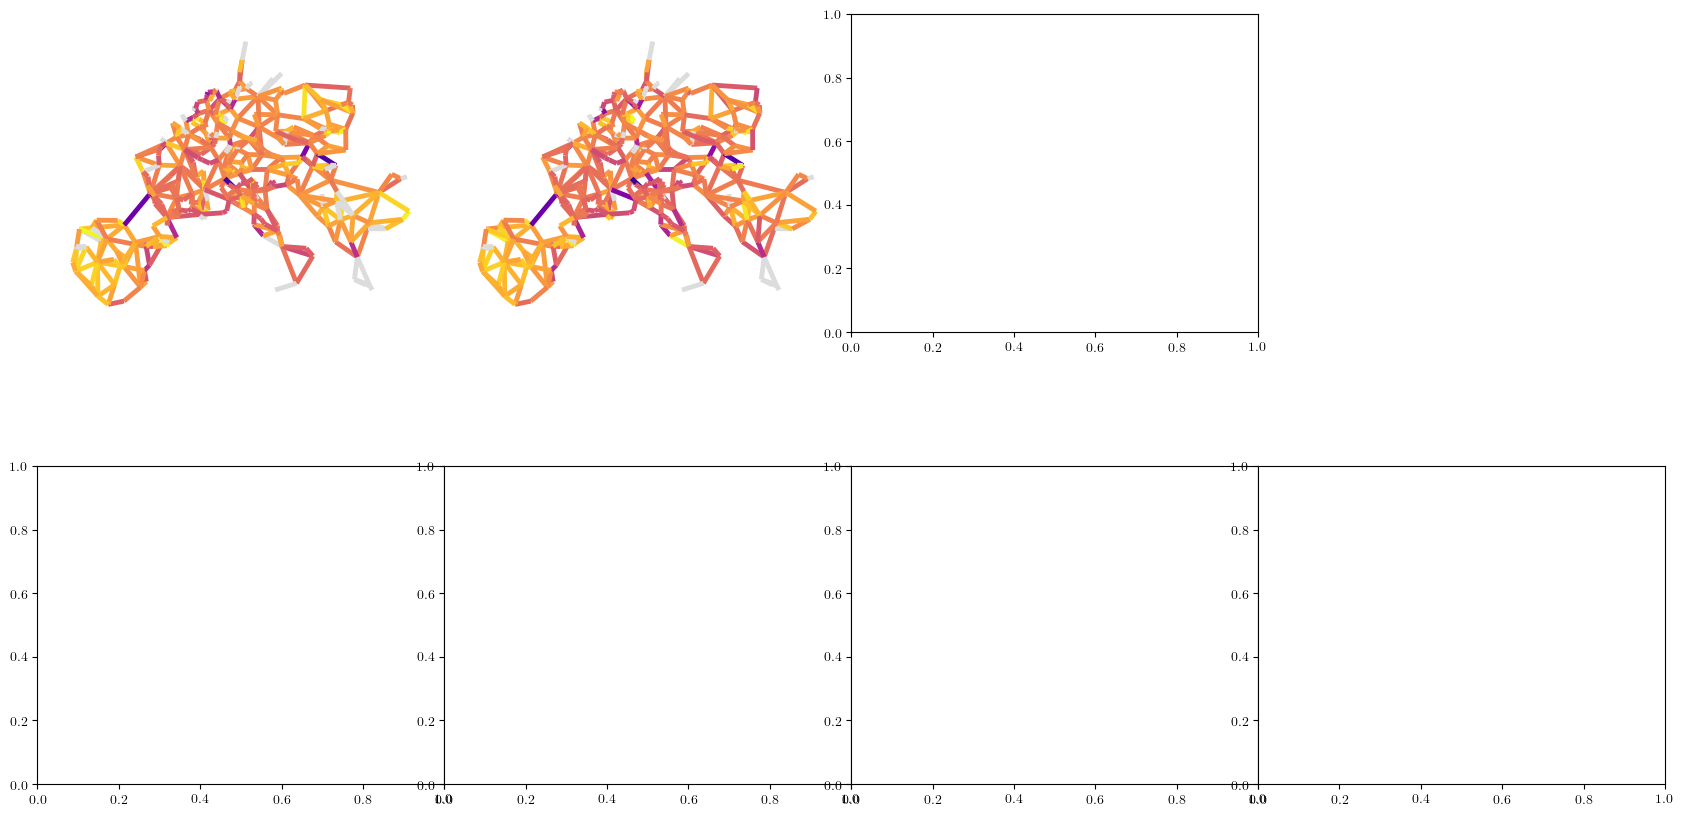

In [44]:
##### setup figure #####
f = plt.figure(figsize=(21, 10))
gs = GridSpec(5, 4, figure=f)
axs_clust = [f.add_subplot(gs[:2, i]) for i in range(3)]
axs2 = [f.add_subplot(gs[3:5, i]) for i in range(4)]
f.subplots_adjust(hspace=-0.1, wspace=0.0)
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

##### setup parameters #####
labels = [r'\textbf{a}', r'\textbf{b}', r'\textbf{c}', r'\textbf{d}']
vmaxvals = []
vminvals = []

#### Primary failures ######

cmap = copy.copy(mpl.cm.get_cmap("plasma_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_p = [edge_likelihoods_primary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_p_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_p])

    print('Min val prim: {:e}'.format(np.amin(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    print('Max val prim: {:e}'.format(np.amax(np.array(c_H_p)[np.array(c_H_p)>1e-12])))
    
    vmax = 1e-3
    # vmax = 10**max(c_H_p_log)
    vmin =  1e-6

    nodes = nx.draw_networkx_nodes(nx_graph,
                                pos=pos,
                                ax=axs_clust[count],
                                node_color='black',
                                node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                pos=pos,
                                ax=axs_clust[count],
                                edge_color=c_H_p_log,
                                width=3.5,
                                edge_cmap=cmap,
                                edge_vmin=np.log10(vmin),
                                edge_vmax=np.log10(vmax))

    axs_clust[count].axis('off')


cbar_ax = f.add_axes([0.9, 0.57, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=cbar_ax)
cb.ax.tick_params(labelsize=26, width=1.0, which='both')
axs_clust[3].text(0.95, 0.95,
            r'$\langle p_{\ell}^{\text{p}}\rangle$',
            fontsize=25,
            weight='bold',
            verticalalignment='center',
            transform=axs_clust[3].transAxes)

###### Secondary failures #####

cmap = copy.copy(mpl.cm.get_cmap("viridis_r"))
cmap.set_under('gainsboro', 1.0)

for count, co2l in enumerate(selected_co2ls[::-1]):

    level = np.round(co2l, 2)
    
    # Load likelihoods as dictionary and transform into array
    c_H_s = [edge_likelihoods_secondary[level][(u, v)] for u, v in nx_graph.edges()]
    c_H_s_log = np.array([np.log10(x) if x > 1e-12 else -np.inf for x in c_H_s])
    
    print('Min val sec: {:e}'.format(np.amin(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    print('Max val sec: {:e}'.format(np.amax(np.array(c_H_s)[np.array(c_H_s)>1e-12])))
    # vmax = 1e-3
    # vmax = 10**max(c_H_s_log)
    vmax = 1e-3
    vmin = 1e-5
    vmaxvals.append(vmax)
    vminvals.append(vmin)

    nodes = nx.draw_networkx_nodes(nx_graph,
                                   pos=pos,
                                   ax=axs2[count],
                                   node_color='black',
                                   node_size=0)

    edges = nx.draw_networkx_edges(nx_graph,
                                   pos=pos,
                                   ax=axs2[count],
                                   edge_color=c_H_s_log,
                                   width=3.5,
                                   edge_cmap=cmap,
                                   edge_vmin=np.log10(vmin),
                                   edge_vmax=np.log10(vmax))

    axs2[count].axis('off')

    axs_clust[count].set_title(r'CO$_2 =$ ' + '{} \%'.format(int(co2l*100)), fontsize=28)
    axs_clust[count].text(0 - 0.075, 1+0.05,
                    labels[count],
                    fontsize=30,
                    weight='bold',
                    verticalalignment='center',
                    transform=axs_clust[count].transAxes)


cbar_ax = f.add_axes([0.9, 0.19, 0.005, 0.25]) # f.add_axes([0.89, 0.35, 0.005, 0.45])
sm = plt.cm.ScalarMappable(
    cmap=cmap, norm=mplcolors.LogNorm(vmin=vmin, vmax=vmax))
cb = f.colorbar(sm, cax=cbar_ax)
# cb.set_ticks([1e-5,1e-4, 1e-3, vmax], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$',r'$1.5\cdot10^{-3}$'])
cb.set_ticks([1e-5,1e-4, 1e-3], labels= [r'$10^{-5}$',r'$10^{-4}$',r'$10^{-3}$'])
cb.ax.tick_params(labelsize=26, width=1.0, which='major')
# cb.ax.yaxis.set_ticks([1e-6,1e-4,1e-2,1])

# minortcs = np.arange(1,10,1)
# minortcs = np.array([minortcs*1e-7,minortcs*1e-6,minortcs*1e-5,minortcs*1e-4,minortcs*1e-3]).flatten()
# minortcs = minortcs[(minortcs>vmin) & (minortcs<vmax)]
# cb.ax.yaxis.set_ticks(minortcs, minor=True)

axs2[3].text(0.95, 0.95,
             r'$\langle p_{\ell}^{\textrm{s}}\rangle$',
             fontsize=25,
             weight='bold',
             verticalalignment='center',
             transform=axs2[3].transAxes)
print(np.max(vmaxvals), np.min(vminvals))


plt.savefig(save_path+'fig7.pdf',bbox_inches = 'tight')


In [17]:
max(c_H_s_log)

-3.0399927174340924

In [ ]:
10**c_H_p_log.max()

0.0015025999816419139

ToDo: Include snapshots weighting in probability! (This happens in script number 4) Done

Check: vmin/vmax choice -> high vmin turn links to gray color which might be confused with no failure probability, but this may not be true!

# Figure 5

In [46]:
co2ls = np.arange(0.1,0.81,0.1).round(1)
selected_co2ls = np.array([0.1, 0.3, 0.6, 0.8])

# Load split component properties
component_props = pd.read_hdf(path_to_vis_results + 'component_properties_all_n400.h5')
component_props.time_stamp = pd.to_datetime(component_props.time_stamp)
# indicator_vectors = np.load(path_to_vis_results + f'indicator_vectors_all_n400.npy').astype(bool)
split_props = pd.read_hdf(path_to_vis_results + 'split_properties_all_n400.h5')
# split_vectors = np.load(path_to_vis_results + f'split_vectors_all_n400.npy')


In [47]:
from utils.config import path_to_evaluation_results
component_props_0 = pd.read_hdf(
            path_to_evaluation_results + f"component_properties_Co2L{0.1}_n{n_nodes}.h5",
            key="df"
            #    , mode= 'w'
        )

In [6]:
split_props

n_components     lost_load  \
co2l time_stamp          split_number                               
0.1  2013-12-15 04:00:00 0.0                      2   4927.250000   
                         1.0                      2      0.000000   
                         2.0                      4    445.215222   
                         3.0                      2     82.611486   
                         4.0                      2   2824.882787   
...                                             ...           ...   
0.8  2013-12-31 19:00:00 508.0                    4  32247.051908   
                         509.0                    2   1072.236813   
                         510.0                    2    570.219950   
                         511.0                    3    570.219950   
                         512.0                    2    345.075121   

                                       lost_load_share        category  
co2l time_stamp          split_number                                   
0.1  2013-12-15 04:00:00 0.0                  0.019819  local_blackout  
                         1.0                  0.000000      negligible  
                         2.0                  0.001791  local_blackout  
                         3.0                  0.000332  local_blackout  
                         4.0                  0.011363  local_blackout  
...                                                ...             ...  
0.8  2013-12-31 19:00:00 508.0                0.122690  local_blackout  
                         509.0                0.004080  local_blackout  
                         510.0                0.002170  local_blackout  
                         511.0                0.002170  local_blackout  
                         512.0                0.001313  local_blackout  

[10823701 rows x 4 columns]

In [48]:
#TODO: remove this when all splits were evaluated!!!
# Restricting analysis to minimum of available time steps

# n_steps_to_consider = component_props.groupby('co2l').apply(lambda x:x.time_stamp.unique().shape[0]).min()
# number_of_simulations = n_steps_to_consider*len(n_2_failures)
# component_props = component_props[pd.to_datetime(component_props.time_stamp)<network.snapshots[n_steps_to_consider]]
component_props["snapshot_weighting"] = network.snapshot_weightings.generators[component_props.time_stamp].values
# indicator_vectors = indicator_vectors[:component_props.shape[0]]

# split_props = split_props[pd.to_datetime(split_props.index.get_level_values('time_stamp'))<network.snapshots[n_steps_to_consider]]
# split_vectors = split_vectors[:split_props.shape[0]]

# n_steps_to_consider


split_props["snapshot_weighting"] = network.snapshot_weightings.generators[split_props.index.get_level_values(1)].values
weighted_split_props_dict = dict({co2l:{category: 0 for category in split_props.category.unique()} for co2l in co2ls})
for index,row in split_props.iterrows():
        weighted_split_props_dict[index[0]][row.category] += row.snapshot_weighting

* **negligible**: there is a component with with >99% load that survives
* **relevant split without blackout/ Non-severe**: Not negligible and not blackout.
* **locally severe/ local blackout**: blackout of <99% of CE load
* **globally severe/ global blackout**: Blackout of >99% of CE load.




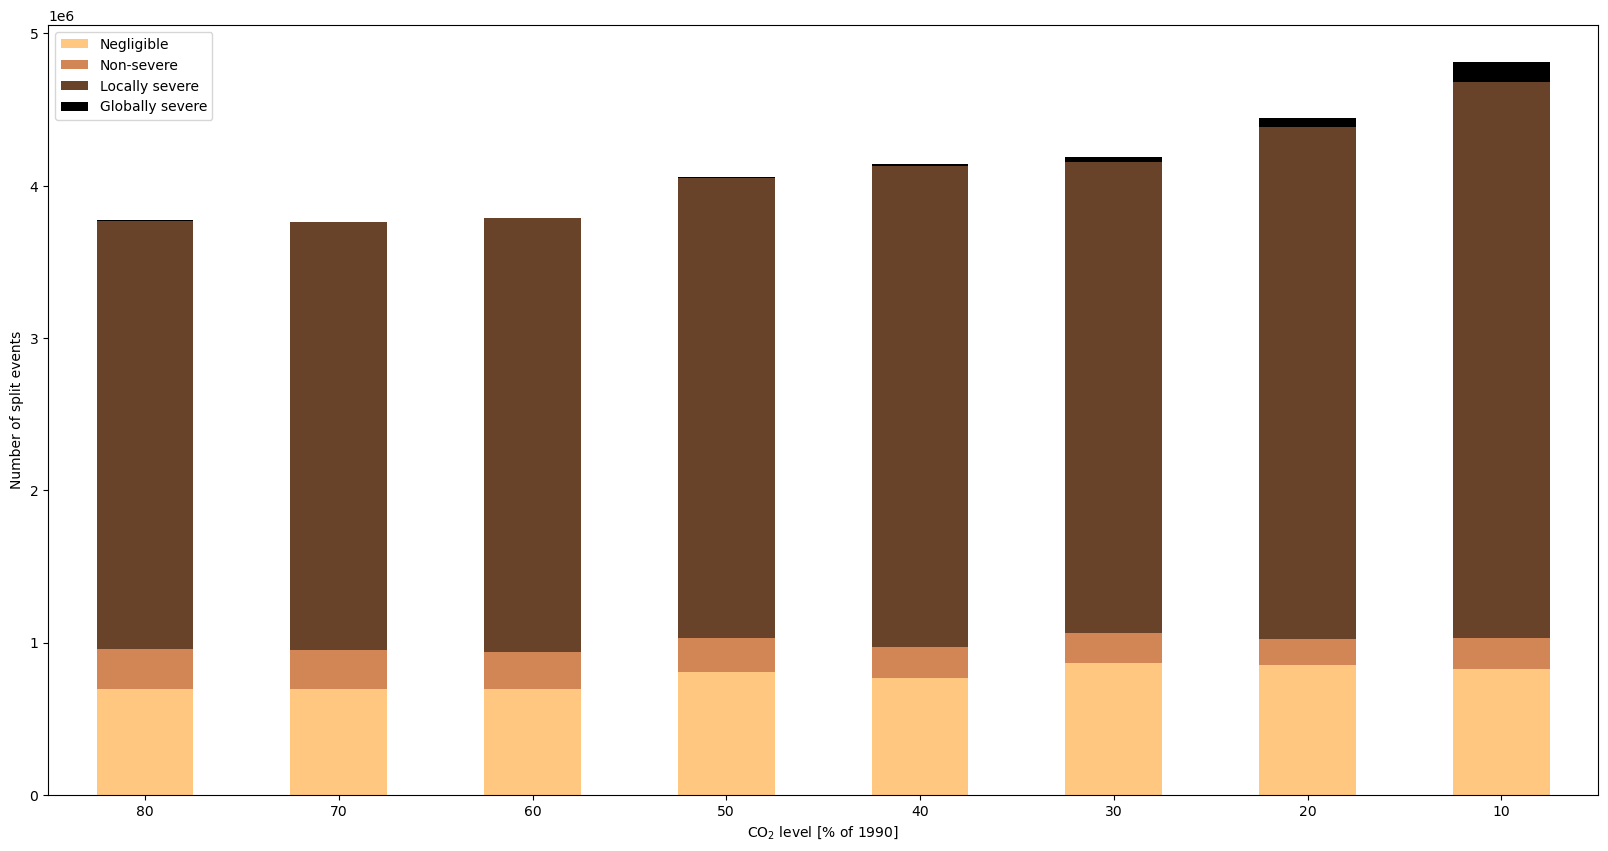

In [17]:
f, ax = plt.subplots(figsize=(20, 10))

data0 = pd.DataFrame(weighted_split_props_dict).transpose()

# data0 = split_props.category.groupby(level=0).value_counts().unstack(1)
data0 = data0.reindex(columns=['global_blackout', 'local_blackout', 'no_blackout', 'negligible'])
data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
                            'no_blackout':'Non-severe','negligible':'Negligible'})
data0 = data0.iloc[:, ::-1]
data0.plot(kind='bar', stacked=True, rot=0, cmap='copper_r', legend=False, ax=ax)

ax.set_xlabel(r'CO$_2$ level [% of 1990]')
ax.set_xticklabels((100*co2ls).astype(int))
ax.set_ylabel('Number of split events')
ax.invert_xaxis()
ax.legend()

/tmp/ipykernel_23222/3526934401.py:78: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_yticklabels((ax4.get_yticks()*100).astype(int))
/tmp/ipykernel_23222/3526934401.py:81: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels((100*co2ls).astype(int))


AttributeError: 'NoneType' object has no attribute 'remove'

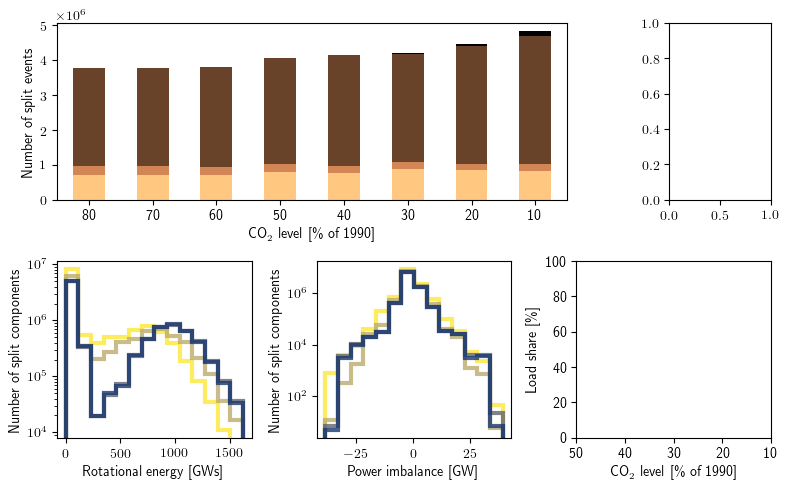

In [49]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

fig = plt.figure(figsize=(8, 5))
gs = GridSpec(2, 3, figure=fig)


# Panel a: split number and categories
gsTop = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0,:], hspace=0, width_ratios=[5,1])
ax1 = fig.add_subplot(gsTop[0, 0])
ax1_legend = fig.add_subplot(gsTop[0, 1])
# add snapshot weighting

data0 = pd.DataFrame(weighted_split_props_dict).transpose()

# data0 = split_props.category.groupby(level=0).value_counts().unstack(1)
data0 = data0.reindex(columns=['global_blackout', 'local_blackout', 'no_blackout', 'negligible'])
data0 = data0.rename(columns={'global_blackout':'Globally severe','local_blackout':'Locally severe',
                            'no_blackout':'Non-severe','negligible':'Negligible'})
data0 = data0.iloc[:, ::-1]
data0.plot(kind='bar', stacked=True, ax=ax1, rot=0, cmap='copper_r', legend=False)
ax1.set_xlabel(r'CO$_2$ level [\% of 1990]')
ax1.set_xticklabels((100*co2ls).astype(int))
ax1.set_ylabel('Number of split events')
ax1.invert_xaxis()

# Panel b: Inertia histograms
cmap = plt.get_cmap('cividis_r')

ax2 = fig.add_subplot(gs[1, 0])
rot_energy = component_props.rot_energy/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
for co2l in selected_co2ls:
    ax2.hist(rot_energy[component_props.co2l==co2l],
            weights=component_props.snapshot_weighting[component_props.co2l==co2l],
            bins=bins,
            histtype='step',
            label=r'{} \%'.format(int(100*co2l)),
            linewidth=3,
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax2.set_yscale('log')
ax2.set_xlabel('Rotational energy [GWs]')
ax2.set_ylabel('Number of split components')

# Panel c: power imbalance histograms

ax3 = fig.add_subplot(gs[1, 1])
rot_energy = component_props.power_imbalance/1000
bins = np.linspace(rot_energy.min(),rot_energy.max(),15)
chandles = []
for co2l in selected_co2ls:
    h= ax3.hist(rot_energy[component_props.co2l==co2l],
            weights=component_props.snapshot_weighting[component_props.co2l==co2l],
            bins=bins,
            histtype='step',
            linewidth=3,
            label=r'{} \%'.format(int(100*co2l)),
            color=cmap(np.where(co2ls == co2l)[0][0]/len(co2ls)),
            alpha=0.8,
            density=False)
ax3.set_yscale('log')
ax3.set_ylabel('Number of split components')
ax3.set_xlabel('Power imbalance [GW]')


# Panel d: Load share strip plots

ax4 = fig.add_subplot(gs[1, 2])
data = component_props.copy()
# duplicate rows according to snapshot weighting
data_duplicates = pd.concat([data[data.snapshot_weighting==weight] for weight in data.snapshot_weighting.unique() for i in range(int(weight))])
data_duplicates.loc[:,'Component blackout'] = data_duplicates.loc[:,'rocof'].abs()>1
# sns.stripplot(data=data_duplicates, x="co2l", y="load_share", hue="Component blackout",
#               palette='bwr', jitter=True, s=1, marker=".", linewidth=0, alpha=.05, ax=ax4, legend=True)
ax4.set_yticklabels((ax4.get_yticks()*100).astype(int))
ax4.set_ylabel(r'Load share [\%]')
ax4.set_xlabel(r'CO$_2$ level [\% of 1990]')
ax4.set_xticklabels((100*co2ls).astype(int))
ax4.invert_xaxis()
h, l = ax4.get_legend_handles_labels()

# Legends
fig.tight_layout()
h, l = ax1.get_legend_handles_labels()
ax1.get_legend().remove()
ax1_legend.legend(h, l, title='Split category')
ax1_legend.axis("off")
# ax1_legend.legend(title='Split category')

ax3.legend(bbox_to_anchor=(0.65,-0.35), ncols=4, title=r'CO$_2$ level [\% of 1990]')
ax4.legend(h,[r'$|$RoCoF$|$ $<$ 1 Hz/s', r'$|$RoCoF$|$ $>$ 1 Hz/s'], bbox_to_anchor=(0.85,-0.35), title='Split components with')
ax1.legend(title='Split category')

# plt.savefig(save_path+'fig5.pdf',bbox_inches = 'tight')

In [19]:
data_duplicates = pd.concat([data[data.snapshot_weighting==weight] for weight in data.snapshot_weighting.unique() for i in range(int(weight))])
data_duplicates.loc[:,'Component blackout'] = data_duplicates.loc[:,'rocof'].abs()>1

In [ ]:
fig.savefig(save_path+'fig5.png',bbox_inches = 'tight', dpi=300)

ToDo: Include snapshot weightings! Done

In [ ]:
# Share of splits with certain amounts of components
nof_comps = component_props.groupby(by=['co2l','time_stamp', 'split_number']).size()
print('2 comps [%]:', 100*(nof_comps==2).sum()/nof_comps.shape[0])
print('3 comps [%]:', 100*(nof_comps==3).sum()/nof_comps.shape[0])
print('4 comps [%]:', 100*(nof_comps==4).sum()/nof_comps.shape[0])

2 comps [%]: 59.12770401085415
3 comps [%]: 14.570788298245347
4 comps [%]: 5.7853255484244706


# Figure 6: Original version

Note: The component clustering apparently does not run for all components due to memory overload. So if you want to use the original component clustering, select a subset of components for the clustering!

In [ ]:
# Print Unique number of split components
uni_comps = np.unique(indicator_vectors, axis=0) 
print('There are',uni_comps.shape[0], 'unique components in',  indicator_vectors.shape[0], 'indicator vectors.')
print('They were grouped into', component_props.cluster_label.unique().shape, 'clusters.')

There are 1693 unique components in 247879 indicator vectors.
They were grouped into (37,) clusters.


In [ ]:
# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
cluster_props = component_props.groupby(
    ['cluster_label', 'co2l']).size().to_frame('counts')
cluster_props.loc[:, 'likelihood'] = cluster_props.counts.div(
    number_of_simulations)

cluster_props = cluster_props.reindex(pd.MultiIndex.from_product([component_props.cluster_label.unique(),
                                                                  component_props.co2l.unique()],
                                                                 names=['cluster_label','co2l'])).sort_index()

# Risk values
for co2l in tqdm(co2ls):
    for label in cluster_props.index.unique(level='cluster_label'):
        sel_comp_props = component_props[(component_props.cluster_label==label) & (component_props.co2l == co2l)]
        if (label!=-1) and (sel_comp_props.shape[0]!=0):
            expected_loss_of_load_share = (sel_comp_props.load_share*(sel_comp_props.rocof.abs()>1)).sum()/sel_comp_props.shape[0]
            cluster_props.loc[(label, co2l), 'expected_loss_of_load_share'] = expected_loss_of_load_share

# this DataFrame has a Multiindex (cluster_label, co2l)
cluster_props.tail()


  0%|          | 0/9 [00:00<?, ?it/s]

counts  likelihood  expected_loss_of_load_share
cluster_label co2l                                                 
39.0          0.4      NaN         NaN                          NaN
              0.5      NaN         NaN                          NaN
              0.6      NaN         NaN                          NaN
              0.7      NaN         NaN                          NaN
              0.8      NaN         NaN                          NaN

In [ ]:
# Select clusters to display: 
# Eight most probable clusters with expected_loss_of_load_share > 0.01 
selected_cluster = cluster_props.expected_loss_of_load_share.max(level='cluster_label').to_frame('max_risk')
selected_cluster.loc[:, 'max_probability'] = cluster_props.likelihood.max(level='cluster_label')
selected_cluster = selected_cluster[(selected_cluster.max_risk>0.01)].sort_values('max_probability').iloc[-8:]

sel_cluster_props = cluster_props.loc[selected_cluster.index].copy()
selected_cluster

/tmp/ipykernel_13007/1807295195.py:3: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  selected_cluster = cluster_props.expected_loss_of_load_share.max(level='cluster_label').to_frame('max_risk')
/tmp/ipykernel_13007/1807295195.py:4: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  selected_cluster.loc[:, 'max_probability'] = cluster_props.likelihood.max(level='cluster_label')


,max_risk,max_probability
cluster_label,,
12.0,0.728609,0.002520
18.0,0.543021,0.002689
2.0,0.360318,0.002829
14.0,0.123241,0.003889
32.0,0.388769,0.005194
15.0,0.067546,0.005899
4.0,0.056212,0.024799
1.0,0.015941,0.091680


0 12.0
12.0
1 18.0
18.0
2 2.0
2.0
3 14.0
14.0
4 32.0
32.0
5 15.0
15.0
6 4.0
4.0
7 1.0
1.0


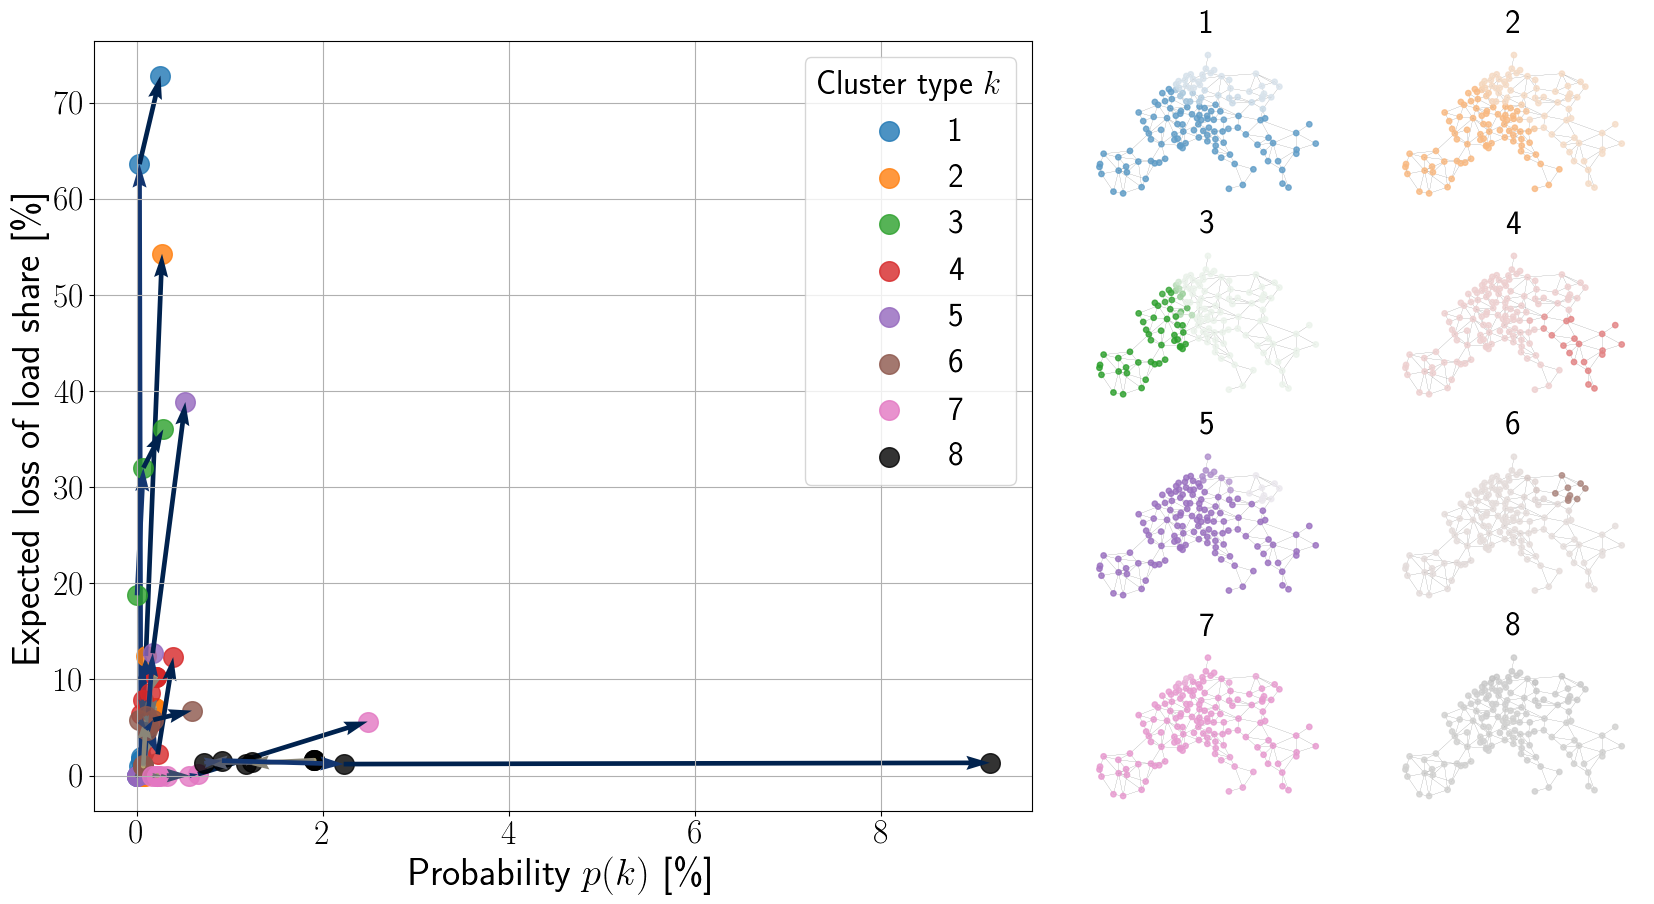

In [ ]:
# fig. 6

# Setup figure
from palettable.colorbrewer.sequential import YlGnBu_9
from palettable.cartocolors.sequential import agSunset_7
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
f = plt.figure(figsize=(20, 10))
gs = GridSpec(4, 6, figure=f, width_ratios=[1,1,1,1,1.3,1.3], height_ratios=[1,1,1,1])

# Prepare axes for map plots.
# Only plot 8 most important cluster
axs_clust = []
for i in range(4):
    axs_clust.append([])
    for j in range(2):
        axs_clust[i].append(f.add_subplot(gs[i, j+4]))
        axs_clust[i][j].axis('off')

# Prepare axis for risk-probability plot
axs_probs = f.add_subplot(gs[:, :4])
axs_probs.grid(True)


########### Probability-risk plot ##############


cmap = YlGnBu_9.mpl_colormap  # agSunset_7.mpl_colormap #Solar_3.mpl_colormap
# [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')
cluster_colors = sns.color_palette('tab10', selected_cluster.shape[0])
cluster_colors[-1]= (0,0,0)
co2_cmap = plt.get_cmap('cividis')
co2_colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]
start_index = 6


for i, cluster in enumerate(selected_cluster.index):
    print(i, cluster)

    # Extract likelihood-risk points for different co2 levels
    points = np.array([sel_cluster_props.loc[cluster].likelihood*100,
                       sel_cluster_props.loc[cluster].expected_loss_of_load_share*100]).T  # ['mean_neg_rocof']]).T#

    # Plot likelihood-risk points
    axs_probs.scatter(points[:, 0],
               points[:, 1],
               s=200,
               color=cluster_colors[i],
               label=str(i+1),  # cluster,
               alpha=0.8)


    # Plot arrows between likelihood-risk points (indicating step-wise co2 reduction)
    axs_probs.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
              (points[:-1, 0]-points[1:, 0])[::-1],
              (points[:-1, 1]-points[1:, 1])[::-1],
              angles='xy',
              scale_units='xy',
              scale=1,
              width=0.005,  # 0.004,
              color=co2_colors)

    print(cluster)

#ax.set_yscale('log')
#ax.set_xscale('log')
axs_probs.set_xlabel('Probability $p(k)$ [\%]', fontsize=28)
axs_probs.set_ylabel('Expected loss of load share [\%]', fontsize=28)
axs_probs.tick_params(axis='both', which='both', labelsize=24)
leg=axs_probs.legend(fontsize=24)
leg.set_title('Cluster type $k$',prop={'size':24})

#ax.set_ylim([2e-1, 5e5])

############# Plots maps with split cluster ###############

selected_ind_vectors = indicator_vectors[component_props.cluster_label.isin(
    selected_cluster.index)]
selected_cluster_labels = component_props[component_props.cluster_label.isin(
    selected_cluster.index)].cluster_label


for i, label in enumerate(selected_cluster.index):
    xcoord = int(i//2)
    ycoord = int(i % 2)
    cmap2 = sns.light_palette(
        cmap((i+1)/(selected_cluster.shape[0]+1)), as_cmap=True)

    mean_ind_vector = np.array(
        [selected_ind_vectors[selected_cluster_labels.values == label].mean(0)])

    nx.draw(nx_graph,
            pos=pos,
            node_size=15,
            width=0.1,
            alpha=0.8,
            ax=axs_clust[xcoord][ycoord],
            node_color=mean_ind_vector,
            cmap=sns.light_palette(cluster_colors[i], as_cmap=True),
            vmin=0,
            vmax=1)

    axs_clust[xcoord][ycoord].set_title('{}'.format(str(i+1)),  # label
                                  fontsize=24)

plt.savefig(save_path + 'fig6_risk_probability_plot.pdf', dpi=200, bbox_inches='tight')


# Figure 6: alternative ideas

Potential problems in original figure:
* Cluster likelihood might be > 1, if a cluster label turns up multiple times in a split event. This can happen when e.g. 1-node components are summarised in one cluster. Should we define the likelihood differently?
* Similarily, check the calculation of expectation of load loss

Moreover, there are >5 components in some splits. The component clustering might not capture these very small components and therefore ignore events where e.g. east Europe splits into multipe small clusters:

<Axes: >

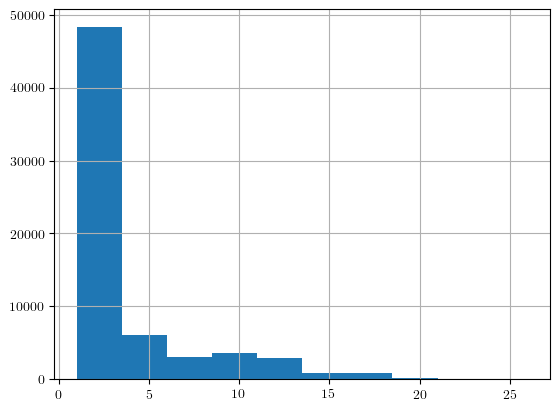

In [ ]:
split_props.n_components.hist()

### Cluster splits

Alternatively we could cluster split events using the RoCoF vector or Imbalance vector (or a non-linear transformation thereof) as an indicator vector for a split.

Here, the split_vectors are the RoCoF values within the component.

(array([1041244.,  785258.,  890250., 2068745., 2129176., 1511363.,
         234055.,   73123.,   76339.,  767609.]),
 array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ]),
 <BarContainer object of 10 artists>)

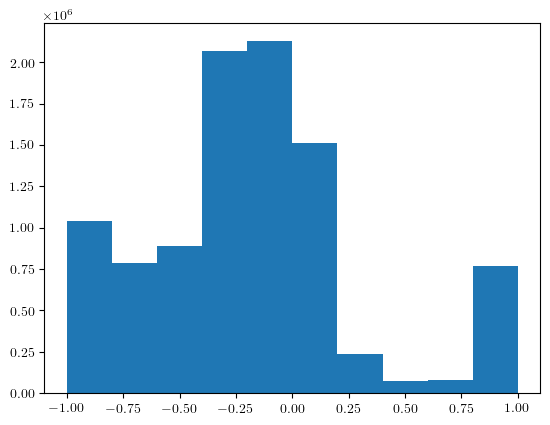

In [ ]:
split_vectors_trans = np.tanh(split_vectors)

plt.hist(split_vectors_trans.flatten())

Optimize cluster with elbow method for k-means

  0%|          | 0/22 [00:00<?, ?it/s]

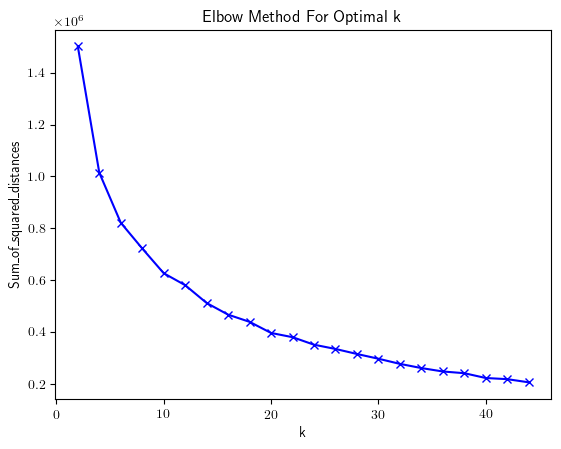

In [ ]:
Sum_of_squared_distances = []
k_test = np.arange(2,45,2)

for k in tqdm(k_test):
    km = KMeans(init="k-means++", n_init=10, n_clusters=k)
    km = km.fit(split_vectors_trans)
    Sum_of_squared_distances.append(km.inertia_)


plt.plot(k_test, Sum_of_squared_distances, 'bx-')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
best_n_clusters = 8
km = KMeans(init="k-means++", n_init=10, n_clusters=best_n_clusters)
km = km.fit(split_vectors_trans)
split_props.loc[:,'cluster_label'] = km.labels_

/tmp/ipykernel_30507/2229261299.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  split_props.loc[:,'cluster_label'] = km.labels_


### Plot split cluster

In [ ]:
# Construct cluster properties and add likelihood of cluster given a certain co2 level
# (Likelihood = Prob. that split of this cluster occurs at random time and initial failure)
split_cluster_props = split_props.groupby(
    ['cluster_label', 'co2l']).size().to_frame('counts')
split_cluster_props.loc[:, 'likelihood'] = split_cluster_props.counts.div(
    number_of_simulations)

split_cluster_props = split_cluster_props.reindex(pd.MultiIndex.from_product([split_props.cluster_label.unique(),
                                                                  co2ls],
                                                                 names=['cluster_label','co2l'])).sort_index()

# Risk values
for co2l in tqdm(co2ls):
    for label in split_cluster_props.index.unique(level='cluster_label'):        
        
        sel_split_props = split_props[(split_props.cluster_label==label) & (split_props.index.get_level_values('co2l') == co2l)]
        split_cluster_props.loc[(label, co2l), 'expected_loss_of_load_share'] = sel_split_props.lost_load_share.mean()

# this DataFrame has a Multiindex (cluster_label, co2l)
split_cluster_props = split_cluster_props.fillna(0)

# Select clusters to display: 
# Eight most probable clusters with expected_loss_of_load_share > 0.01 
selected_cluster = split_cluster_props.expected_loss_of_load_share.max(level='cluster_label').to_frame('max_risk')
selected_cluster.loc[:, 'max_probability'] = split_cluster_props.likelihood.max(level='cluster_label')
selected_cluster = selected_cluster[(selected_cluster.max_risk>0.01)].sort_values('max_probability').iloc[-8:]

sel_cluster_props = split_cluster_props.loc[selected_cluster.index].copy()
selected_cluster


  0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_30507/3533908497.py:24: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  selected_cluster = split_cluster_props.expected_loss_of_load_share.max(level='cluster_label').to_frame('max_risk')
/tmp/ipykernel_30507/3533908497.py:25: FutureWarning: Using the level keyword in DataFrame and Series aggregations is deprecated and will be removed in a future version. Use groupby instead. df.median(level=1) should use df.groupby(level=1).median().
  selected_cluster.loc[:, 'max_probability'] = split_cluster_props.likelihood.max(level='cluster_label')


,max_risk,max_probability
cluster_label,,
3,0.986837,0.001474
4,0.999856,0.002138
7,0.998900,0.002388
5,0.753303,0.003809
6,0.369797,0.003892
1,0.884955,0.004247
2,0.230938,0.010900
0,0.316771,0.012454


0 3
3
1 4
4
2 7
7
3 5
5
4 6
6
5 1
1
6 2
2
7 0
0


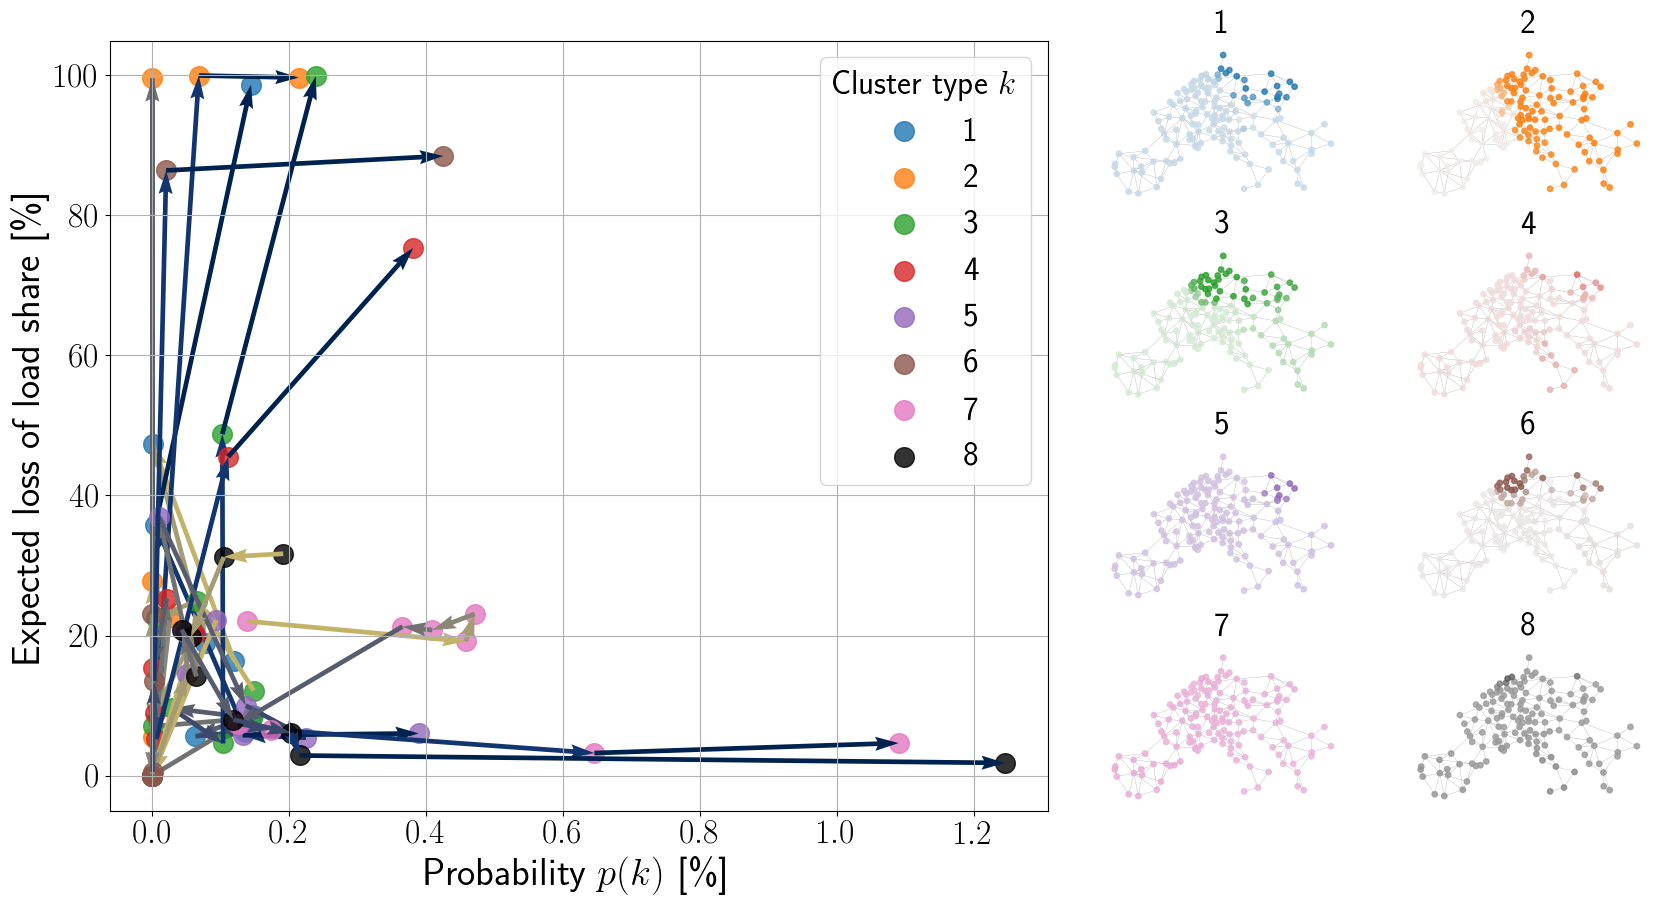

In [ ]:
# fig. 6

# Setup figure
from palettable.colorbrewer.sequential import YlGnBu_9
from palettable.cartocolors.sequential import agSunset_7
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
f = plt.figure(figsize=(20, 10))
gs = GridSpec(4, 6, figure=f, width_ratios=[1,1,1,1,1.3,1.3], height_ratios=[1,1,1,1])

# Prepare axes for map plots.
# Only plot 8 most important cluster
axs_clust = []
for i in range(4):
    axs_clust.append([])
    for j in range(2):
        axs_clust[i].append(f.add_subplot(gs[i, j+4]))
        axs_clust[i][j].axis('off')

# Prepare axis for risk-probability plot
axs_probs = f.add_subplot(gs[:, :4])
axs_probs.grid(True)


########### Probability-risk plot ##############


cmap = YlGnBu_9.mpl_colormap  # agSunset_7.mpl_colormap #Solar_3.mpl_colormap
# [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')
cluster_colors = sns.color_palette('tab10', selected_cluster.shape[0])
cluster_colors[-1]= (0,0,0)
co2_cmap = plt.get_cmap('cividis')
co2_colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls)-1)][::-1]
start_index = 6


for i, cluster in enumerate(selected_cluster.index):
    print(i, cluster)

    # Extract likelihood-risk points for different co2 levels
    points = np.array([sel_cluster_props.loc[cluster].likelihood*100,
                       sel_cluster_props.loc[cluster].expected_loss_of_load_share*100]).T  # ['mean_neg_rocof']]).T#

    # Plot likelihood-risk points
    axs_probs.scatter(points[:, 0],
               points[:, 1],
               s=200,
               color=cluster_colors[i],
               label=str(i+1),  # cluster,
               alpha=0.8)


    # Plot arrows between likelihood-risk points (indicating step-wise co2 reduction)
    axs_probs.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
              (points[:-1, 0]-points[1:, 0])[::-1],
              (points[:-1, 1]-points[1:, 1])[::-1],
              angles='xy',
              scale_units='xy',
              scale=1,
              width=0.005,  # 0.004,
              color=co2_colors)

    print(cluster)

#ax.set_yscale('log')
#ax.set_xscale('log')
axs_probs.set_xlabel('Probability $p(k)$ [\%]', fontsize=28)
axs_probs.set_ylabel('Expected loss of load share [\%]', fontsize=28)
axs_probs.tick_params(axis='both', which='both', labelsize=24)
leg=axs_probs.legend(fontsize=24)
leg.set_title('Cluster type $k$',prop={'size':24})

#ax.set_ylim([2e-1, 5e5])

############# Plots maps with split cluster ###############


for i, label in enumerate(selected_cluster.index):
    xcoord = int(i//2)
    ycoord = int(i % 2)

    mean_ind_vector = km.cluster_centers_[label]

    nx.draw(nx_graph,
            pos=pos,
            node_size=15,
            width=0.1,
            alpha=0.8,
            ax=axs_clust[xcoord][ycoord],
            node_color=mean_ind_vector,
            cmap=sns.light_palette(cluster_colors[i], as_cmap=True),
            vmin=-1,
            vmax=1)

    axs_clust[xcoord][ycoord].set_title('{}'.format(str(i+1)),  # label
                                  fontsize=24)

#plt.savefig(save_path + 'fig6_risk_probability_plot.pdf', dpi=200, bbox_inches='tight')

0 3
3
1 4
4
2 7
7
3 5
5
4 6
6
5 1
1
6 2
2
7 0
0


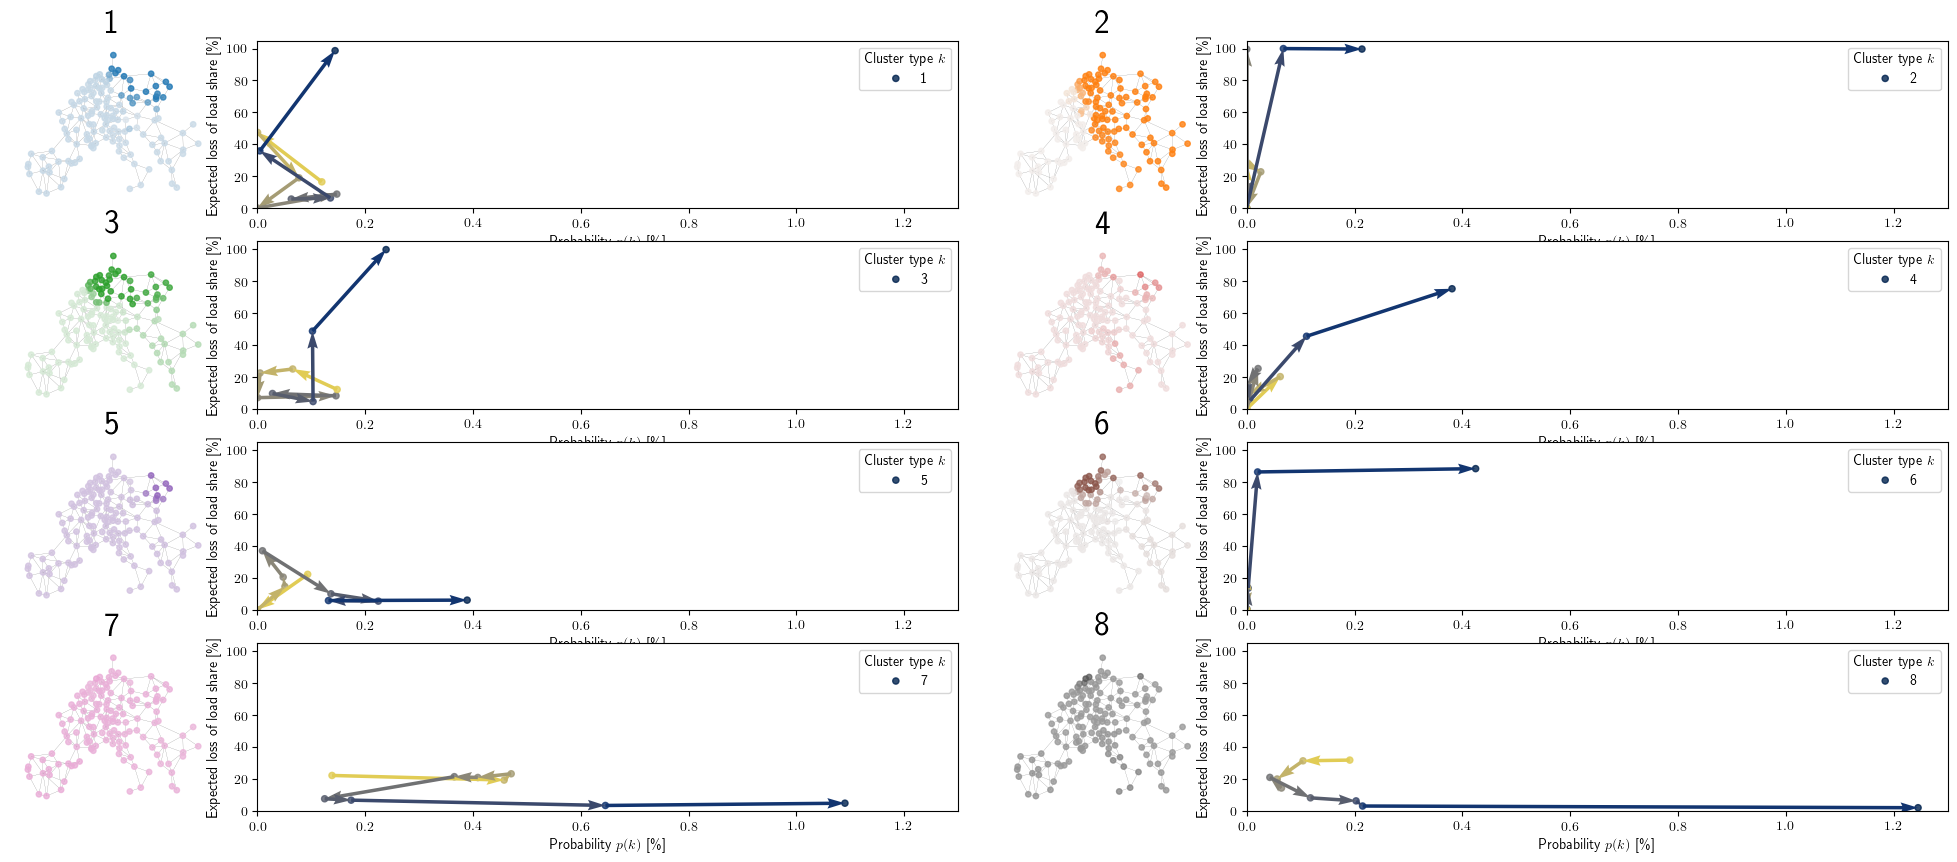

In [ ]:
# fig. 6

# Setup figure
from palettable.colorbrewer.sequential import YlGnBu_9
from palettable.cartocolors.sequential import agSunset_7
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
f = plt.figure(figsize=(25, 10))
gs = GridSpec(4, 8, figure=f, width_ratios=[1 for i in range(8)], height_ratios=[1,1,1,1])
# gs = GridSpec(4, 8, figure=f, width_ratios=[1,1,1,1,1.3,1.3], height_ratios=[1,1,1,1])

# Prepare axes for map plots.
# Only plot 8 most important cluster
axs_clust = []
axs_probs = []

for i in range(4):
    axs_clust.append([])
    # axs_probs.append([])
    
    for j,j_ind in enumerate([0,4]):
        axs_clust[i].append(f.add_subplot(gs[i, j_ind]))
        axs_clust[i][j].axis('off')
        
        axs_probs.append(f.add_subplot(gs[i, j_ind+1:j_ind+4]))
        # axs_probs[i].grid(True)

# Prepare axis for risk-probability plot
# axs_probs = f.add_subplot(gs[:, :4])
# axs_probs.grid(True)


########### Probability-risk plot ##############


cmap = YlGnBu_9.mpl_colormap  # agSunset_7.mpl_colormap #Solar_3.mpl_colormap
# [cmap((i+1)/(len(selected_cluster)+1)) for i in range(len(selected_cluster))]#sns.color_palette('colorblind')
cluster_colors = sns.color_palette('tab10', selected_cluster.shape[0])
cluster_colors[-1]= (0,0,0)
co2_cmap = plt.get_cmap('cividis')
co2_colors = [co2_cmap(i/len(co2ls)) for i in range(len(co2ls))][::-1]
start_index = 6


for i, (cluster, axs_prob) in enumerate(zip(selected_cluster.index, axs_probs)):
    print(i, cluster)

    # Extract likelihood-risk points for different co2 levels
    points = np.array([sel_cluster_props.loc[cluster].likelihood*100,
                       sel_cluster_props.loc[cluster].expected_loss_of_load_share*100]).T  # ['mean_neg_rocof']]).T#

    # Plot likelihood-risk points
    axs_prob.scatter(points[:, 0],
               points[:, 1],
               s=20,
            #    color=cluster_colors[i],
                c=co2_colors[::-1],
               label=str(i+1),  # cluster,
               alpha=0.8)


    # Plot arrows between likelihood-risk points (indicating step-wise co2 reduction)
    axs_prob.quiver(points[1:, 0][::-1], points[1:, 1][::-1],
              (points[:-1, 0]-points[1:, 0])[::-1],
              (points[:-1, 1]-points[1:, 1])[::-1],
              angles='xy',
              scale_units='xy',
              scale=1,
              width=0.005,  # 0.004,
              color=co2_colors)

    print(cluster)

#ax.set_yscale('log')
#ax.set_xscale('log')
    axs_prob.set_xlabel('Probability $p(k)$ [\%]', )
    axs_prob.set_ylabel('Expected loss of load share [\%]', )
    axs_prob.set_xlim([0, 1.3])
    axs_prob.set_ylim([0, 105])
    axs_prob.tick_params(axis='both', which='both', )
    leg=axs_prob.legend()
    leg.set_title('Cluster type $k$',prop={'size':None})

#ax.set_ylim([2e-1, 5e5])

############# Plots maps with split cluster ###############


for i, label in enumerate(selected_cluster.index):
    xcoord = int(i//2)
    ycoord = int(i % 2)

    mean_ind_vector = km.cluster_centers_[label]

    nx.draw(nx_graph,
            pos=pos,
            node_size=15,
            width=0.1,
            alpha=0.8,
            ax=axs_clust[xcoord][ycoord],
            node_color=mean_ind_vector,
            cmap=sns.light_palette(cluster_colors[i], as_cmap=True),
            vmin=-1,
            vmax=1)

    axs_clust[xcoord][ycoord].set_title('{}'.format(str(i+1)),  # label
                                  fontsize=24)

#plt.savefig(save_path + 'fig6_risk_probability_plot.pdf', dpi=200, bbox_inches='tight')

In [ ]:
axs_probs

[[<Axes: >, <Axes: >],
 [<Axes: >, <Axes: >],
 [<Axes: >, <Axes: >],
 [<Axes: >, <Axes: >]]

Problem: By taking tanh(rocof), a split will end up in another cluster if the power flows are opposite, i.e., rocof -> -rocof . Do we want this? 

Shouldn't we focus on negative rocofs since positive ones are rather harmless?

Note: Depending on the interpretation of the mean cluster vector, one could use diverging colormaps here, instead of "light_palette", e.g., showing the positive and negative RoCoFs.

## Additional plot for Figure 1

NameError: name 'G' is not defined

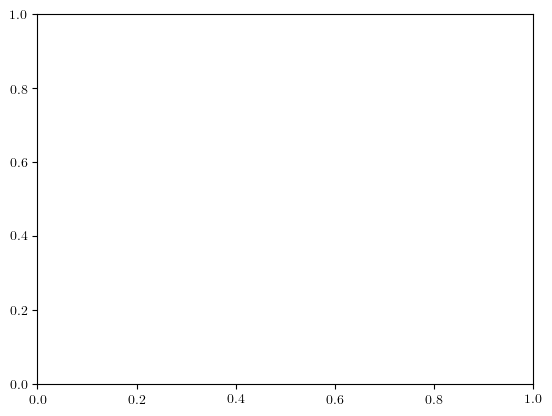

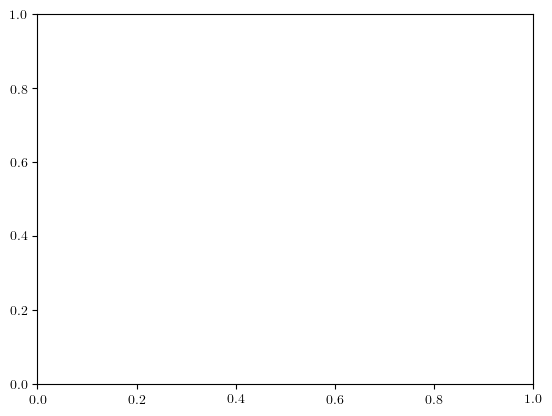

In [ ]:

fig_before, ax_before = plt.subplots()
fig_concept, ax_concept = plt.subplots()

i = 5
label = selected_cluster.index[i]

cmap2 = sns.light_palette(
    cmap((i+1)/(selected_cluster.shape[0]+1)), as_cmap=True)

mean_ind_vector = np.array(
    [selected_ind_vectors[selected_cluster_labels.values == label].mean(0)])

networks_opts = dict(pos=pos, node_size=20, edge_color='k',
                     width=.8, alpha=1,
                     edgecolors='k', vmin=0, vmax=1)

nx.draw(G,
        ax=ax_before,
        node_color='gray',
        **networks_opts
       )

nx.draw(G,
        ax=ax_concept,
        node_color=mean_ind_vector,
        cmap=sns.light_palette('r', as_cmap=True),
        **networks_opts
       )

fig_concept.savefig(save_path + 'schema_eu.svg')
fig_before.savefig(save_path + 'schema_eu_before.svg')

plt.show()

# Supplements: Generation mix vs co2 level

NameError: name 'pypsa' is not defined

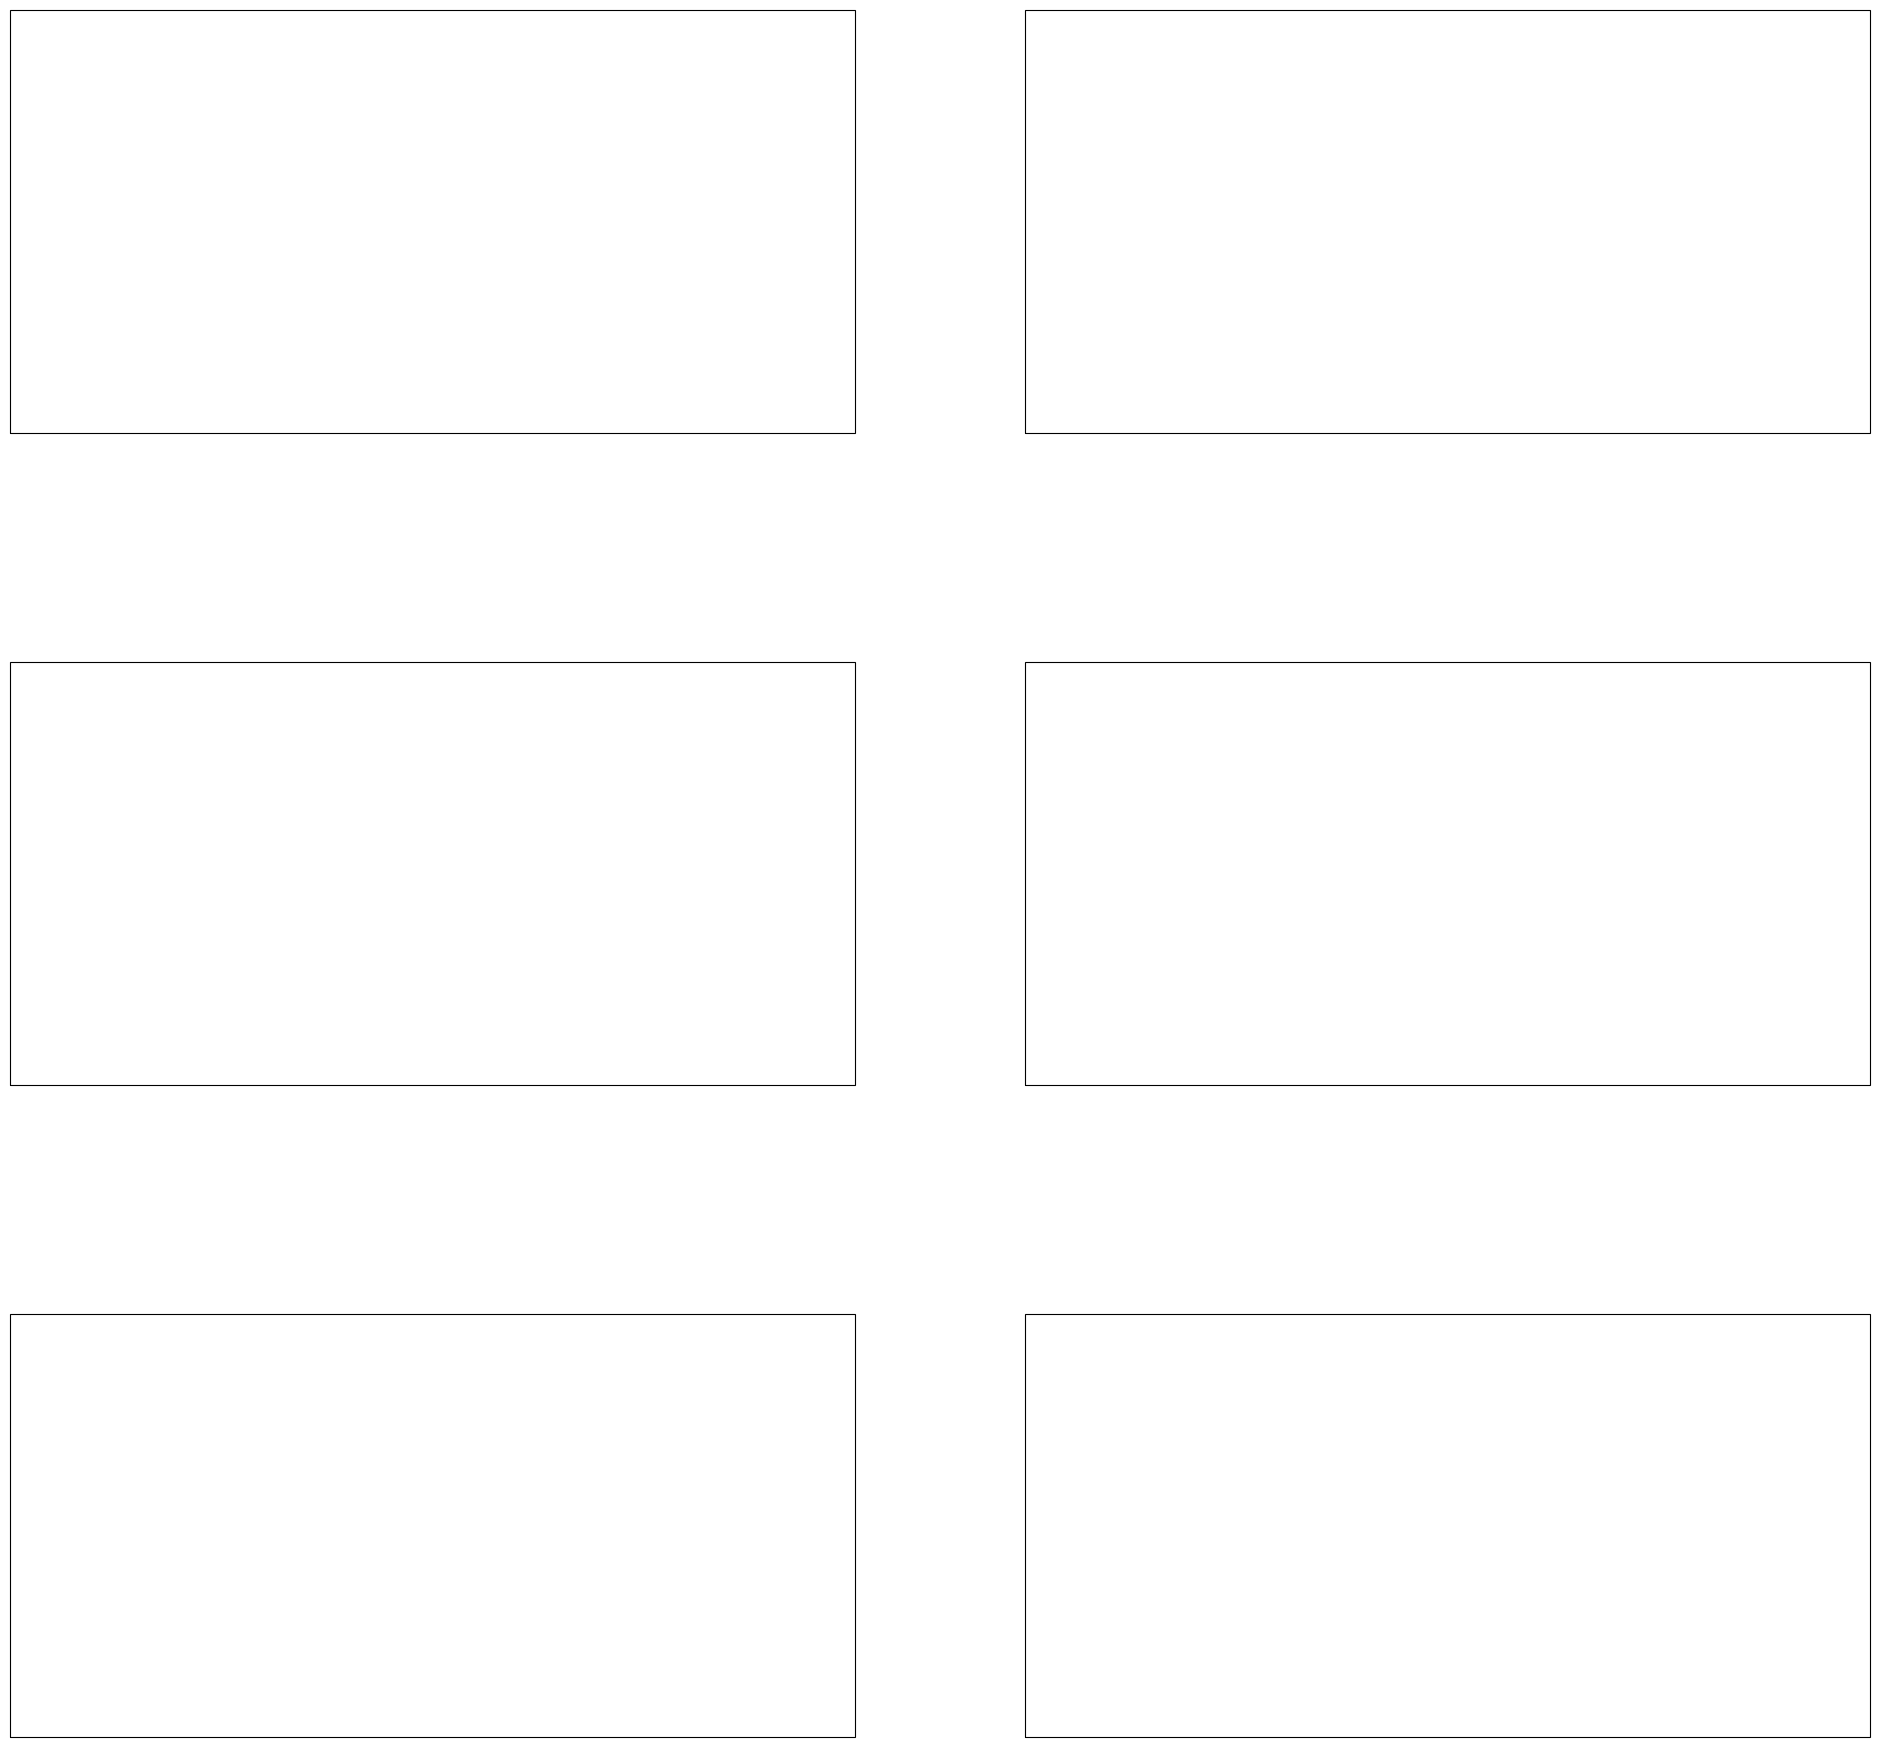

In [ ]:
mpl.style.use('default')
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}\usepackage{bm}')

target_levels = [0.0, 0.40, 0.80]

f, axs_probs = plt.subplots(3, 2, figsize=(24, 24), subplot_kw={
                     "projection": ccrs.PlateCarree()})
vmax = 3.2e2
months = [1, 7]

labels = [[r'\textbf{a}', r'\textbf{b}', r'\textbf{c}'],
          [r'\textbf{c}', '', r'\textbf{d}', '', '']]

for i, ind in enumerate(target_levels):

    n = pypsa.Network()
    n.import_from_netcdf(path_to_pypsa_network +
                         f'elec_s_800_ec_lv1.0_Co2L{ind}-3H.nc')

    for j, month in enumerate(months):

        axs_probs[i, j].set_ylim([0, vmax])
        current_snapshots = n.snapshots[n.snapshots.month == month]

        n.plot(bus_sizes=n.generators_t.p.loc[current_snapshots].sum().groupby([n.generators["bus"], n.generators["carrier"]]).sum()/2e6,
               line_colors='black',
               link_colors='black',
               link_widths=0.5,
               line_widths=0.5,
               ax=axs_probs[i, j])

        if i == 0:
            axs_probs[i, j].set_title(current_snapshots.month_name()[0], fontsize=24)
        if j == 0:
            axs_probs[i, j].text(0 - 0.1, 1+0.05,
                          labels[j][i],
                          fontsize=36,
                          weight='bold',
                          verticalalignment='center',
                          transform=axs_probs[i, j].transAxes)

            axs_probs[i, j].text(0 - 0.4, 0.5,
                          r'CO$_2$ level = '+str(ind),
                          fontsize=24,
                          verticalalignment='center',
                          transform=axs_probs[i, j].transAxes)
plt.tight_layout()
# plt.savefig(save_path+'Figures/SI_Generation_mix_versus_co2level.pdf',bbox_inches='tight')
plt.show()


# Supplements: Line loading histogram

In [ ]:
# calculate line flows

bins = np.arange(0, 1.0, 0.02)

co2ls = np.arange(0.0, 1.0, 0.2)

hist_vals = np.zeros((len(co2ls), len(bins)-1))


for count, co2l in enumerate(selected_co2ls):

    path_to_pypsa_network = path + \
        'Data/system_split/European_Networks/New_networks_CO2_levels/'
    results_path = path + 'Data/system_split/European_Networks/New_networks_CO2_levels/Results/'

    network = pypsa.Network()
    currentlevel = np.round(co2l, 2)
    network.import_from_netcdf(
        path_to_pypsa_network+f'elec_s_800_ec_lv1.0_Co2L{currentlevel}-3H.nc')

    snet_index = 0

    G = utils.build_networkx_graph(network, snet_index=snet_index)

    indices = nx.get_edge_attributes(G, 'line_index')
    line_limits = nx.get_edge_attributes(G, 's_nom')

    for e, index_list in tqdm(indices.items()):
        loadings = np.abs(
            network.lines_t.p0.T.loc[index_list[0]]/line_limits[e])
        current_hist = np.histogram(loadings, bins)[0]
        hist_vals[count] += current_hist
    # for e, index_list in indices.items()}


/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=df.index | columns, fill_value=default)
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:771: FutureWarning: Index.__or__ operating as a set operation is deprecated, in the future this will be a logical operation matching Series.__or__.  Use index.union(other) instead
  pnl[attr] = pnl[attr].reindex(columns=(pnl[attr].columns | columns))
INFO:pypsa.io:Imported network elec_s_800_ec_lv1.0_Co2L0.0-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units
100%|██████████| 1008/1008 [00:00<00:00, 1455.03it/s]
/home/fkaiser/.conda/envs/system_split/lib/python3.9/site-packages/pypsa/io.py:769: FutureWarning: Index.__or__ operating as

In [ ]:
xpoints = (bins + (bins[1]-bins[0])/2)[1:]

co2ls = np.arange(0.0, 1.0, 0.05)

f, axs_probs = plt.subplots(figsize=(12, 6))

for count, co2l in enumerate(selected_co2ls[::-1]):

    ind = np.where(np.round(co2ls, 2) == co2l)[0][0]

    axs_probs.step(xpoints,
            hist_vals[3-count]/np.sum(hist_vals[3-count]),
            label=r'$\text{CO}_2\text{ level} = %.2f$' % co2l,
            linewidth=2,
            color=cmap(ind/len(co2ls)),
            alpha=0.8)
axs_probs.legend(fontsize=16)
#width = (bins[1]-bins[0])/2,
# label = 'data')
axs_probs.set_xlim([0, 0.8])
axs_probs.tick_params(axis='both', which='both', labelsize=16)
axs_probs.set_xlabel(r'relative line loading', fontsize=16)
axs_probs.set_ylabel(r'relative frequency', fontsize=16)
axs_probs.grid(True)
# ax.set_yscale('log')
# ax.set_ylim([4e-3,1e-1])
#plt.savefig(save_path+'Figures/SI_line_utilization_versus_CO2.pdf',bbox_inches = 'tight')

plt.show()


# Figure 8

#TODO: Update inertia placement functions in utils and update the code for Figure 8

In [ ]:
# VaR of reference level
ref_level = 0.55
q=0.995
var_ref_value = visualisation.val_at_risk(component_props[component_props.co2l==round(ref_level,2)],
                                  number_of_simulations, q, method='abs')
print(ref_level, var_ref_value)


0.55 0.5324567602994262


In [ ]:
additional_synthetic_inertia_per_step = 1000 # see 5_calc_inertia_placement.py to get this value 

        new_var  added_node_index
0    769.371720               NaN
1     30.210549             193.0
2     18.970633             526.0
3     12.911468             193.0
4      9.606445             193.0
..          ...               ...
122    0.547273             250.0
123    0.543391             526.0
124    0.538918             193.0
125    0.535379             250.0
126    0.531169             193.0

[127 rows x 2 columns]


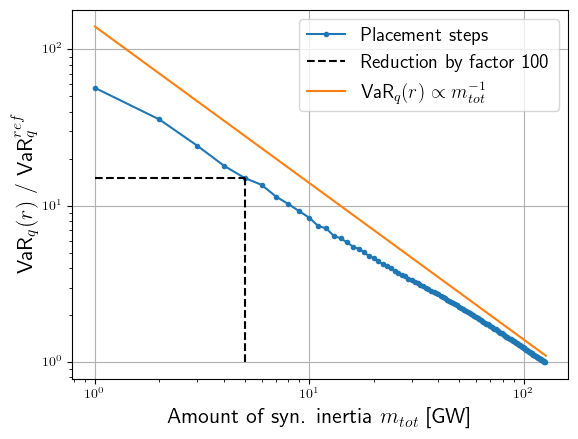

In [ ]:
inertia_placement_co2l00 = pd.read_hdf(path_to_inertia+'inertia_placement_steps_co2l00.h5')
print(inertia_placement_co2l00)
plt.loglog(inertia_placement_co2l00.index[1:]*additional_synthetic_inertia_per_step/1000,
         inertia_placement_co2l00.new_var.values[1:]/var_ref_value, '.-', label='Placement steps')

placement_for_50_perc_red = inertia_placement_co2l00.iloc[np.argmin(np.abs(inertia_placement_co2l00.new_var.values-inertia_placement_co2l00.new_var.max()/100))]
plt.plot([placement_for_50_perc_red.name*additional_synthetic_inertia_per_step/1000,
          placement_for_50_perc_red.name*additional_synthetic_inertia_per_step/1000],
         [1,placement_for_50_perc_red.new_var/var_ref_value], '--', c='k')
plt.plot([additional_synthetic_inertia_per_step/1000, placement_for_50_perc_red.name*additional_synthetic_inertia_per_step/1000],
         [placement_for_50_perc_red.new_var/var_ref_value,placement_for_50_perc_red.new_var/var_ref_value], '--', c='k', label='Reduction by factor 100')

plt.ylabel(r'VaR$_q(r)$ / VaR$_q^{ref}$', fontsize=16)
plt.xlabel('Amount of syn. inertia $m_{tot}$ [GW]', fontsize=16)
#plt.ylim([inertia_placement_co2l00.new_var.min(),inertia_placement_co2l00.new_var[1:].max()])
#plt.yscale('log')
plt.grid()
xs = np.linspace(additional_synthetic_inertia_per_step,
                inertia_placement_co2l00.shape[0]*additional_synthetic_inertia_per_step,
                100)/1000
plt.loglog(xs, 140/xs, '-', label=r'VaR$_q(r) \propto m_{tot}^{-1}$')
plt.legend(fontsize=14)
plt.savefig(save_path+'SI_inertia_placement_steps_co2l00.pdf', bbox_inches='tight', dpi=200)

In [ ]:
nodal_inertia_co2l00=inertia_placement_co2l00.groupby('added_node_index').size().to_frame('syn_inertia_mw')
nodal_inertia_co2l00=nodal_inertia_co2l00.reindex(range(len(G)),
                                                          fill_value=0)*additional_synthetic_inertia_per_step
nodal_inertia_co2l00

,syn_inertia_mw
added_node_index,
0,0
1,0
2,0
3,0
4,0
...,...
603,0
604,0
605,0


In [ ]:
total_syn_inertia_vs_co2l = pd.Series(index=co2ls.round(2), dtype=float)

for co2l in co2ls:
    inertia_placement = pd.read_hdf(path_to_inertia+'inertia_placement_steps_co2l{:02.0f}.h5'.format(100*co2l))
    total_syn_inertia_vs_co2l.loc[round(co2l,2)] = (inertia_placement.shape[0]-1)*additional_synthetic_inertia_per_step

total_syn_inertia_vs_co2l

0.00    126000.0
0.05     97000.0
0.10     50000.0
0.15     54000.0
0.20     68000.0
0.25     69000.0
0.30     52000.0
0.35     66000.0
0.40     31000.0
0.45     25000.0
0.50     11000.0
0.55         0.0
0.60         0.0
0.65         0.0
0.70         0.0
0.75         0.0
0.80         0.0
0.85         0.0
0.90         0.0
0.95         0.0
dtype: float64

In [ ]:
comp_props_co2l00

,co2l,time_stamp,number_of_split,inertia_proxy,load_imbalance,available_flexible_generation,causing_link,cluster_label,rocof,new_inertia,new_rocof
603866,0.0,01_10_2013_00,0.0,68714.224579,-4684.991113,NaN,1039.0,21.0,-2.840867e-01,156714.224579,-0.124563
603867,0.0,01_10_2013_00,0.0,0.000000,4685.012622,NaN,1039.0,32.0,inf,38000.000000,0.513708
603868,0.0,01_10_2013_00,6.0,68714.224579,-4754.473726,NaN,1037.0,21.0,-2.882999e-01,156714.224579,-0.126410
603869,0.0,01_10_2013_00,6.0,0.000000,4754.495235,NaN,1037.0,32.0,inf,38000.000000,0.521326
603870,0.0,01_10_2013_00,9.0,68222.224579,-6624.262287,NaN,79.0,21.0,-4.045763e-01,156222.224579,-0.176678
...,...,...,...,...,...,...,...,...,...,...,...
674718,0.0,31_12_2013_21,61.0,0.000000,6998.819003,NaN,246.0,61.0,inf,62000.000000,0.470351
674719,0.0,31_12_2013_21,62.0,54267.670579,4406.796371,NaN,585.0,266.0,3.383534e-01,154267.670579,0.119025
674720,0.0,31_12_2013_21,62.0,9871.258000,-1947.554254,NaN,585.0,19.0,-8.220644e-01,35871.258000,-0.226220
674721,0.0,31_12_2013_21,71.0,64079.315179,-12492.771706,NaN,322.0,8.0,-8.123248e-01,128079.315179,-0.406414


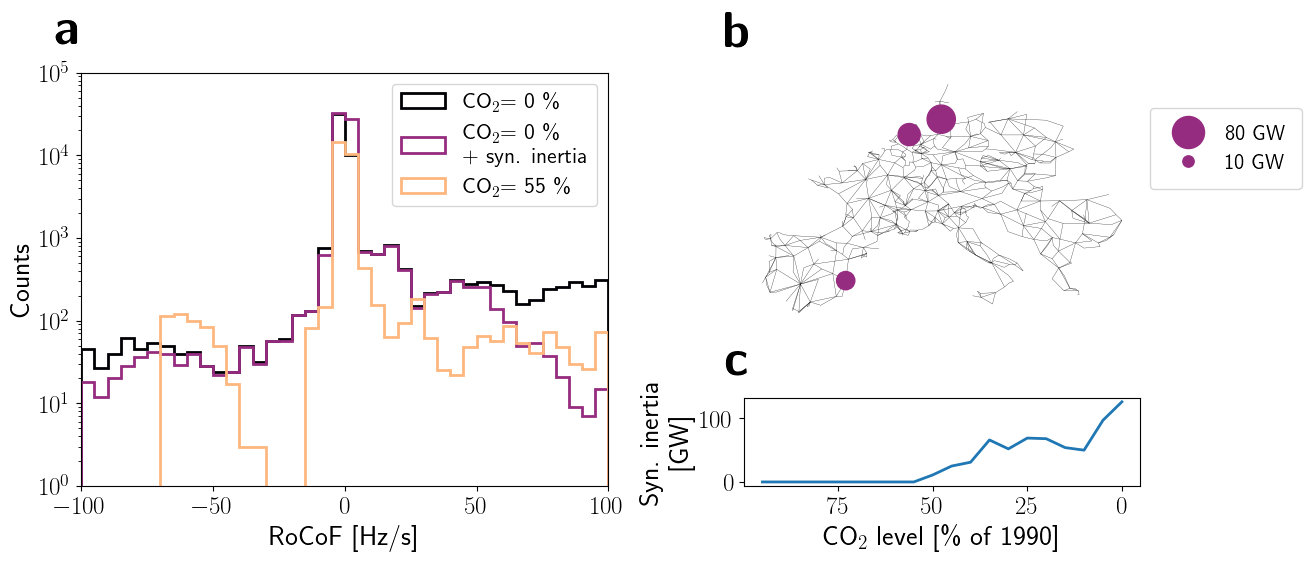

In [ ]:
labels = [r'\textbf{a}', r'\textbf{b}',
          r'\textbf{c}', r'\textbf{d}', r'\textbf{e}']
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
fig = plt.figure(constrained_layout=True, figsize=(13,5.5))
widths = [2,1.5]
heights = [1,0.35]
gs = fig.add_gridspec(ncols=2, nrows=2, width_ratios=widths,
                          height_ratios=heights)



######### Histograms of RoCoF ###########

comp_props_co2l00 = pd.read_hdf(path_to_inertia+'component_props_with_syn_inertia_co2l00.h5')
comp_props_co2l_ref = pd.read_hdf(path_to_inertia+'component_props_with_syn_inertia_co2l55.h5')

vmin = -100
vmax = 100

plot_colors = plt.get_cmap('magma')(np.linspace(0,0.85,3))
axs_probs = fig.add_subplot(gs[:,:1])
axs_probs.hist(comp_props_co2l00.rocof, range=[vmin,vmax], histtype='step',lw=2, label=r'CO$_2$= 0 \%', bins=40, color=plot_colors[0])
axs_probs.hist(comp_props_co2l00.new_rocof, range=[vmin,vmax], histtype='step',lw=2, label=r'CO$_2$= 0 \%'+ '\n'+ '+ syn. inertia', bins=40, color=plot_colors[1])
axs_probs.hist(comp_props_co2l_ref.rocof, range=[vmin,vmax], histtype='step',lw=2, label=r'CO$_2$= 55 \%', bins=40, color=plot_colors[2])
axs_probs.legend(fontsize=16)
axs_probs.set_ylabel('Counts', fontsize=20)
axs_probs.set_xlabel('RoCoF [Hz/s]' , fontsize=20)

axs_probs.text(0 - 0.05, 1+0.1,
         labels[0],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=axs_probs.transAxes)
axs_probs.set_xlim([vmin,vmax])
axs_probs.set_ylim([1,1e5])
axs_probs.set_yscale('log')
axs_probs.tick_params(axis='both', which='both', labelsize=18)

# add VaR values
#orig_var = -inertia_placement_co2l00.new_var.values[0]
new_var = -inertia_placement_co2l00.new_var.values[-1]
#ax.plot([orig_var, orig_var], [1,1e5], '--', lw=4, c=plot_colors[0])
#ax.plot([new_var, new_var], [1,1e5], '--', lw=4, c=plot_colors[1])
#ax.text(-9,1e3, 'Old \nVaR', color=plot_colors[0], size=16)
#ax.text(-8,3e4, 'New VaR', color=plot_colors[1], size=16)


########### Map of 0% co2l syn. inertia placement ###########

axs_probs = fig.add_subplot(gs[0,1])
scalefactor = 150
nx.draw(G,
        pos=pos,
        node_size=nodal_inertia_co2l00.values/scalefactor,
        width=0.2,
        alpha=1,
        ax=axs_probs,
        node_color=plot_colors[1]
        #cmap=sns.light_palette(cluster_colors[i], as_cmap=True),
        #vmin=0,
        #vmax=1
         )

axs_probs.text(0 - 0.05, 1+0.15,
         labels[1],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=axs_probs.transAxes)

p_80gw = mlines.Line2D([], [], color=plot_colors[1], marker='o', linestyle='None',
                          markersize=np.sqrt(80000/scalefactor), label='80 GW', alpha=1)
p_10gw = mlines.Line2D([], [], color=plot_colors[1], marker='o', linestyle='None',
                          markersize=np.sqrt(10000/scalefactor), label='10 GW', alpha=1)
axs_probs.legend(handles=[p_80gw,p_10gw], bbox_to_anchor=(1.,0.9,0,0), ncol=1, fontsize=15,borderpad=0.8)


############ Amount of syn. inertia vs. co2 level ############

axs_probs = fig.add_subplot(gs[1,1])

axs_probs.plot(total_syn_inertia_vs_co2l.div(1000).index*100,total_syn_inertia_vs_co2l.div(1000).values, lw=2)
axs_probs.set_xlabel('CO$_2$ level [\% of 1990]', fontsize=20)
axs_probs.set_ylabel('Syn. inertia \n[GW]', fontsize=20)

axs_probs.text(0 - 0.05, 1+0.4,
         labels[2],
         fontsize=36,
         weight='bold',
         verticalalignment='center',
         transform=axs_probs.transAxes)
axs_probs.tick_params(axis='both', which='both', labelsize=18)
axs_probs.invert_xaxis()

fig.savefig(save_path+'fig8_syn_inertia_placement.pdf', bbox_inches='tight', dpi=200)

In [ ]:
print(comp_props_co2l00.rocof.quantile(0.01))
print(comp_props_co2l00.new_rocof.quantile(0.01))
print(comp_props_co2l95.rocof.quantile(0.01))

-inf
-61.75814958969013
-61.90057085073297


In [ ]:
inertia_placement_co2l00.max()

syn_inertia_mw    90000
dtype: int64